**Solution du Devoir 3 – Entraînement d’un PMC (MLP) et d’un CNN**

Cours : 8IAR403 – Apprentissage Machine pour les Sciences des Données

Session : Hiver 2026

Nom : DIABATE

Prénom : VAMOUSSA

Il convient de noter que l’analyse réalisée dans le cadre du présent Devoir 3 s’inscrit dans la continuité directe des travaux effectués lors des devoirs précédents, notamment le Devoir 2, portant sur l’entraînement et l’évaluation de modèles d’apprentissage supervisé.

Ainsi, pour la première partie **partie 1** de ce devoir, je vais réutiliser les mêmes approches de préparation, de nettoyage et de transformation des données, appliquées sous forme de pipelines de prétraitement, afin d’assurer la cohérence méthodologique avec les travaux antérieurs et de faciliter la comparaison des performances entre les différents modèles.

À l’instar des devoirs précédents, cette première partie s’appuie sur un ensemble de données provenant d’un site de commerce électronique, décrivant les revenus générés par les clients. Le jeu de données Customer.csv contient 10 000 enregistrements et 8 variables (âge, nombre de pages consultées, prix du premier article, genre, réachat, clics sur les actualités, pays, revenu).

L’objectif principal de ce devoir est d’étudier et de mettre en œuvre des modèles d’apprentissage basés sur les réseaux de neurones artificiels, conformément aux notions abordées dans le cours. Les bibliothèques utilisées sont principalement scikit-learn pour la première partie, et TensorFlow / Keras pour la seconde.

Plus précisément, deux grandes parties seront étudiées :

**Partie 2 : Entraînement d’un Perceptron MultiCouches (PMC / MLP)**

Dans cette première partie, nous utiliserons l’algorithme MLPClassifier de la bibliothèque scikit-learn afin de construire deux modèles de classification :

Un classeur binaire, visant à prédire si le revenu d’un client est supérieur à la moyenne (classe 1) ou non (classe 0).

Un classeur multi‑classes, permettant de discriminer trois catégories de revenus : revenu bas, revenu moyen, revenu élevé.

L’étude portera sur la détermination de la meilleure architecture du PMC, notamment :

le nombre de couches cachées (entre 1 et 5)

le nombre de neurones par couche (entre 10 et 100)

la fonction d’activation (relu, tanh, logistic)

le solveur d’optimisation (adam, sgd)

le nombre maximal d’itérations

le taux d’apprentissage

Les modèles seront entraînés et validés à l’aide d’une validation croisée avec k = 3, conformément aux exigences du devoir. Les performances seront évaluées à partir des métriques suivantes :

Accuracy

Précision

Rappel

F1‑score

Une optimisation des hyperparamètres sera également réalisée à l’aide de RandomizedSearchCV, afin d’identifier la configuration la plus performante.

Enfin, le meilleur modèle retenu sera testé sur un jeu de test indépendant afin d’évaluer sa capacité de généralisation.

**Partie 3 : Entraînement d’un réseau de neurones convolutif (CNN)**

Dans la seconde partie, nous nous intéresserons à la classification d’images en utilisant le jeu de données Fashion‑MNIST, fourni par Keras / TensorFlow. Ce jeu contient 70 000 images en niveaux de gris de taille 28 × 28 pixels, réparties en 10 classes d’articles vestimentaires (tee‑shirt, pantalon, pull, robe, manteau, sandale, chemise, sneaker, sac, bottine).

L’objectif ici est de développer un réseau de neurones profond de type CNN capable de classifier automatiquement ces images.

Cette partie comprendra :

la réexécution du modèle PMC fourni en exemple (notebook pmc_avec_keras_fashion_mnist.ipynb)

la conception d’un CNN personnalisé

l’analyse de la courbe d’apprentissage

l’application de l’augmentation de données (ImageDataGenerator)

l’utilisation du transfert d’apprentissage à partir d’un modèle pré‑entraîné (autre que VGG16, par exemple MobileNetV2)

une étude comparative des performances entre les différents modèles

Les critères de comparaison retenus seront :

l’accuracy

le temps d’entraînement (moyenné sur GPU)

le comportement vis‑à‑vis du surapprentissage

## Importation des bibliothèques

Dans cette première étape, nous importons les bibliothèques nécessaires pour la manipulation, l’analyse, la visualisation et le prétraitement des données.  
Ces outils permettront de nettoyer les données, gérer les valeurs manquantes, traiter les valeurs aberrantes, construire des pipelines de transformation et préparer les données pour les modèles de Machine Learning.

Nous débutons par l'importation des bibliothèques nécessaires pour ce projet d'apprentissage machine.
Les bibliothèques utilisées sont:
1. __pandas__, permettant l'importation et la gestion des ensembles de données nécessaires au projet.
2. __numpy__, permettant les manipulations, évaluations et fonctions mathématiques avancées sur les données.
3. __os__, permettant la gestion d'emplacement des fichiers.
4. __matplotlyb__, pour les éléments de visualisation.
5. __sklearn__, pour plusieurs opérations de traitement, mises à l'échelle et de transformation dans un contexte de ML.

In [1]:
# ================================
# IMPORTATION DES BIBLIOTHÈQUES
# ================================

# Manipulation et analyse des données
import pandas as pd
import numpy as np

# Visualisation des données
import matplotlib.pyplot as plt
import seaborn as sns

# Gestion des fichiers et répertoires
import os

# Ignorer les avertissements pour garder un notebook propre
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# BIBLIOTHÈQUES SCIKIT-LEARN (Prétraitement)
# ==========================================

# Création de transformateurs personnalisés
from sklearn.base import BaseEstimator, TransformerMixin

# Transformation de fonctions personnalisées
from sklearn.preprocessing import FunctionTransformer

# Construction de pipelines de traitement
from sklearn.pipeline import Pipeline

# Gestion des valeurs manquantes
from sklearn.impute import SimpleImputer

# Standardisation des données numériques
from sklearn.preprocessing import StandardScaler

# Séparation des données d'entraînement et de test
from sklearn.model_selection import train_test_split

# Validation croisée
from sklearn.model_selection import cross_val_score

# Recherche aléatoire des meilleurs hyperparamètres
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import learning_curve

In [2]:
from google.colab import files
import pandas as pd

# Ouvrir la fenêtre pour sélectionner les fichiers depuis votre PC
uploaded = files.upload()

Saving CountryGDP.csv to CountryGDP.csv
Saving CountryPopulation.csv to CountryPopulation.csv
Saving Customer.csv to Customer.csv


### Chargement des jeux de données

Dans cette étape, nous chargeons les trois fichiers CSV nécessaires à l’étude :

- **Customer.csv** : contient les informations principales sur les clients
- **CountryPopulation.csv** : contient les données de population par pays
- **CountryGDP.csv** : contient les données du PIB par pays

Nous convertissons également les données en tableaux NumPy afin de vérifier leurs dimensions, puis nous affichons les premières lignes de chaque jeu de données pour mieux comprendre leur structure.

In [3]:
# =========================================================
# Chargement des jeux de données
# =========================================================

customer_data = pd.read_csv("Customer.csv")
CountryPopulation_data = pd.read_csv("CountryPopulation.csv")
CountryGDP_data = pd.read_csv("CountryGDP.csv")

# Conversion en tableaux NumPy
Customer_arr = customer_data.to_numpy()
Country_pop_arr = CountryPopulation_data.to_numpy()
CountryGDP_arr = CountryGDP_data.to_numpy()

# Affichage des dimensions
print("Dimensions du fichier Customer :", Customer_arr.shape)
print("Dimensions du fichier CountryPopulation :", Country_pop_arr.shape)
print("Dimensions du fichier CountryGDP :", CountryGDP_arr.shape)

print("\n" + "="*60)

# Aperçu des données
print("Aperçu du fichier Customer :")
print(customer_data.head(10))

print("\nAperçu du fichier CountryPopulation :")
print(CountryPopulation_data.head(10))

print("\nAperçu du fichier CountryGDP :")
print(CountryGDP_data.head(10))

Dimensions du fichier Customer : (10000, 8)
Dimensions du fichier CountryPopulation : (220, 2)
Dimensions du fichier CountryGDP : (188, 2)

Aperçu du fichier Customer :
    age  pages first_item_prize gender  ReBuy  News_click country  revenue
0  41.0    6.0             28.0    Fem  False         4.0   China      113
1  34.0    4.0             15.5    Fem   True         2.0   China       36
2  38.0    5.0                ?    Fem  False         7.0   China      111
3  20.0    1.0             44.0    Fem  False         2.0   China       71
4  39.0   10.0             10.0    Fem   True         4.0   China       80
5  39.0    8.0             44.0    Fem  False         5.0   China  unknown
6  36.0    6.0             44.0   Masc  False         2.0   China       51
7  68.0    4.0             57.0   Masc  False         7.0   China      128
8  42.0    7.0             42.0   Masc   True         5.0   China      114
9  40.0   12.0             42.0    Fem  False         5.0   China      109

Aperç

Partie 1 — Reprise du devoir #2 : Préparation des données et mise en contexte

Dans cette première partie, nous reprenons les principales étapes réalisées dans le devoir #2 afin de préparer correctement les données avant l’entraînement des modèles de réseaux de neurones du devoir #3.

## Reproduction des étapes 2 à 4 de la méthodologie de gestion d’un projet d’apprentissage automatique

Conformément à la méthodologie de gestion d’un projet de machine learning vue en cours, cette section reprend les **étapes 2 à 4**, qui constituent les phases essentielles avant l’entraînement des modèles.

Les étapes reproduites sont les suivantes :

1. **Récupération des données**  
   Cette étape consiste à charger les différents jeux de données nécessaires à l’étude, à vérifier leur disponibilité ainsi que leur structure.

2. **Découverte et visualisation des données pour une meilleure compréhension**  
   Cette phase permet d’explorer les variables disponibles, d’identifier la nature des données, de détecter les valeurs manquantes ou aberrantes et d’obtenir une première compréhension statistique et visuelle du jeu de données.

3. **Préparation des données pour les algorithmes d’apprentissage automatique**  
   Cette étape comprend le nettoyage des données, le traitement des valeurs manquantes, la gestion des valeurs aberrantes, l’encodage des variables catégorielles ainsi que la normalisation ou la standardisation des variables numériques à l’aide de pipelines de transformation.


## 1 Nettoyage des données du jeu de données principal Customer.csv

Dans cette étape, nous commençons par explorer les valeurs manquantes présentes dans le jeu de données `Customer.csv`.  
Pour cela, nous définissons des fonctions permettant :

- de **visualiser graphiquement** le nombre de valeurs manquantes par colonne ;
- de **repérer précisément** les colonnes contenant des données manquantes ;
- de **convertir certaines variables en format numérique**, lorsque cela est nécessaire ;
- de **remplacer les valeurs manquantes** dans les variables numériques à l’aide d’une stratégie d’imputation par la moyenne.

L’objectif est d’obtenir un jeu de données propre, cohérent et exploitable pour les étapes de prétraitement et d’entraînement des modèles.

Informations sur le jeu de données des clients :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               10000 non-null  float64
 1   pages             10000 non-null  float64
 2   first_item_prize  10000 non-null  object 
 3   gender            10000 non-null  object 
 4   ReBuy             10000 non-null  bool   
 5   News_click        10000 non-null  float64
 6   country           10000 non-null  object 
 7   revenue           10000 non-null  object 
dtypes: bool(1), float64(3), object(4)
memory usage: 556.8+ KB
None


Statistiques descriptives des colonnes numériques :
                 age         pages first_item_prize gender  ReBuy  \
count   10000.000000  10000.000000            10000  10000  10000   
unique           NaN           NaN               11      2      2   
top              NaN           NaN           

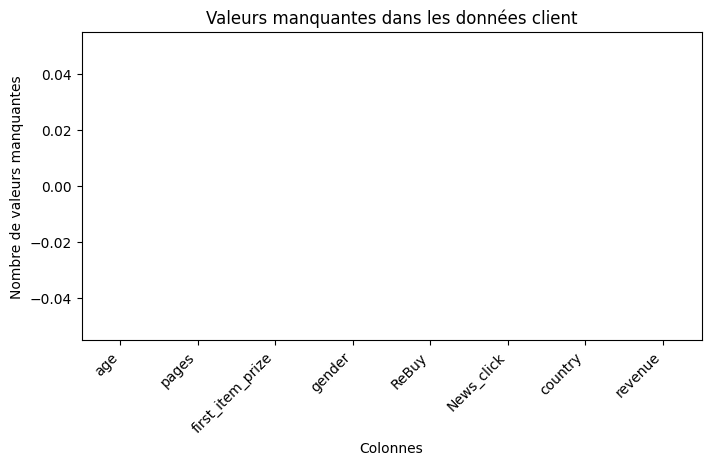



Valeurs manquantes avant la transformation :
Series([], dtype: int64)


Valeurs manquantes après la transformation des valeurs non numériques :
revenue    4
dtype: int64


Statistiques descriptives après l’imputation :
                 age         pages first_item_prize gender         ReBuy  \
count   10000.000000  10000.000000            10000  10000  10000.000000   
unique           NaN           NaN               11      2           NaN   
top              NaN           NaN             44.0    Fem           NaN   
freq             NaN           NaN             2083   6902           NaN   
mean       37.431400      5.995000              NaN    NaN      0.280000   
std         9.490474      2.438559              NaN    NaN      0.449021   
min        18.000000      1.000000              NaN    NaN      0.000000   
25%        31.000000      5.000000              NaN    NaN      0.000000   
50%        37.000000      6.000000              NaN    NaN      0.000000   
75%        43.00000

In [4]:
# Fonction utilisée pour visualiser les valeurs manquantes
def visualize_missing_values(data):
    missing_values_count = data.isnull().sum()
    plt.figure(figsize=(8, 4))
    missing_values_count.plot(kind='bar')
    plt.title('Valeurs manquantes dans les données client')
    plt.xlabel('Colonnes')
    plt.ylabel('Nombre de valeurs manquantes')
    plt.xticks(rotation=45, ha='right')
    plt.show()

def locate_missing_values(data):
    missing_values = data.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    return missing_values

# Convertir les données en valeurs numériques
def transform_to_numeric(data):
    data.replace('unknown', pd.NA, inplace=True)
    data['revenue'] = pd.to_numeric(data['revenue'], errors='coerce')
    # Convertir la colonne booléenne en numérique (True -> 1, False -> 0)
    data['ReBuy'] = data['ReBuy'].astype(int)
    return data

def impute_missing_values(data):
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy='mean')
    data[numeric_columns] = imputer.fit_transform(data[numeric_columns])
    return data

print("Informations sur le jeu de données des clients :")
print(customer_data.info())

print("\n\nStatistiques descriptives des colonnes numériques :")
print(customer_data.describe(include='all'))

visualize_missing_values(customer_data)

print("\n\nValeurs manquantes avant la transformation :")
print(locate_missing_values(customer_data))

customer_data = transform_to_numeric(customer_data)

print("\n\nValeurs manquantes après la transformation des valeurs non numériques :")
print(locate_missing_values(customer_data))

customer_data = impute_missing_values(customer_data)

print("\n\nStatistiques descriptives après l’imputation :")
print(customer_data.describe(include='all'))

## 2. Création d’un pipeline de prétraitement

Dans cette étape, nous mettons en place un pipeline de traitement des données afin d’automatiser certaines opérations de nettoyage.

Ce pipeline permet de :

- remplacer les symboles spéciaux comme `?` par des valeurs manquantes (`NaN`) ;
- convertir la colonne `revenue` en format numérique ;
- préparer les données pour les prochaines étapes de modélisation.

L’utilisation d’un pipeline permet de rendre le traitement plus propre, reproductible et mieux organisé.

In [5]:
class ReplaceSpecialSymbols(BaseEstimator, TransformerMixin):
    def __init__(self, special_symbol='?'):
        self.special_symbol = special_symbol

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        for col in X.columns:
            if col:
                X[col] = X[col].replace(self.special_symbol, np.nan)
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features


# Convertir la colonne 'revenue' en type numérique (Fonction)
def convert_to_numeric(X):
    X['revenue'] = pd.to_numeric(X['revenue'], errors='coerce')
    return X


# Créer un FunctionTransformer pour la conversion numérique
numeric_transformer = FunctionTransformer(convert_to_numeric)


# Définir le pipeline conformément aux exigences
pipeline = Pipeline([
    ('replace_special_symbols', ReplaceSpecialSymbols()),
    ('convert_to_numeric', numeric_transformer)
])


# Appliquer le pipeline aux données
Customer_data_afterPipeLine = pipeline.fit_transform(customer_data)

print(Customer_data_afterPipeLine.columns)

Index(['age', 'pages', 'first_item_prize', 'gender', 'ReBuy', 'News_click',
       'country', 'revenue'],
      dtype='object')


## 3. Détection et traitement des valeurs aberrantes

Dans cette étape, nous analysons les valeurs aberrantes présentes dans les variables numériques du jeu de données.

Nous utilisons la méthode de l’écart interquartile (**IQR**) :

- `Q1` : premier quartile
- `Q3` : troisième quartile
- `IQR = Q3 - Q1`
- une valeur est considérée comme aberrante si elle est trop éloignée de cet intervalle

Les valeurs aberrantes détectées sont remplacées par la médiane de la colonne concernée.  
Des boxplots sont affichés avant et après le traitement afin de visualiser l’effet de cette correction.

Index(['age', 'pages', 'first_item_prize', 'gender', 'ReBuy', 'News_click',
       'country', 'revenue'],
      dtype='object')


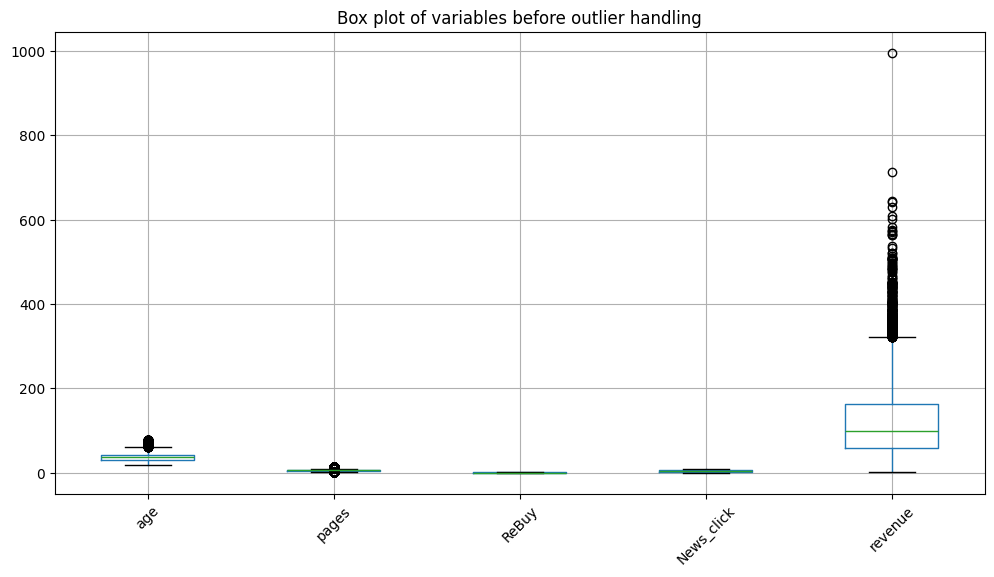

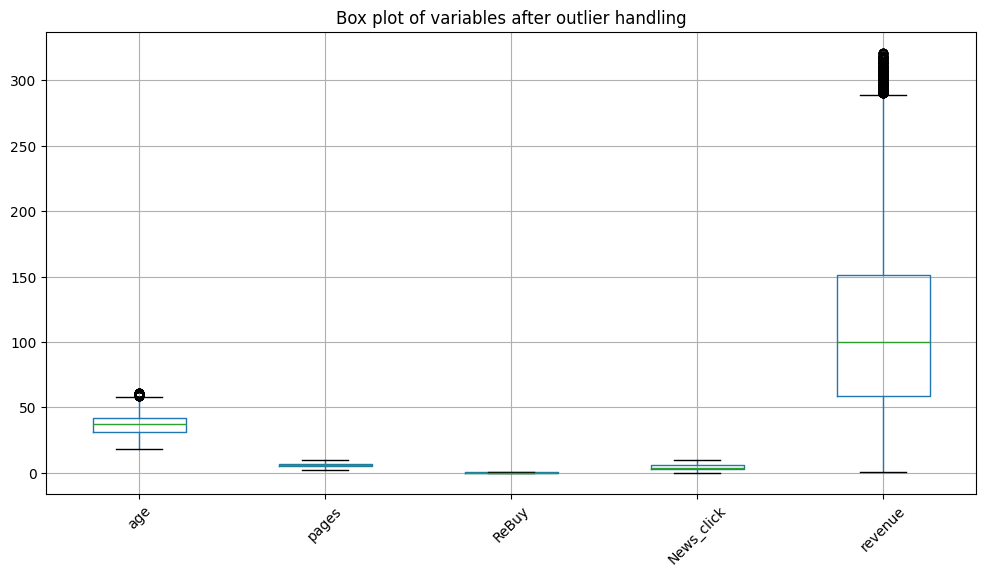

In [6]:
# ------------------------------------------------------------
# Transformateur pour remplacer un symbole spécial (par defaut '?') par NaN
# ------------------------------------------------------------
class ReplaceSpecialSymbols(BaseEstimator, TransformerMixin):
    def __init__(self, special_symbol='?'):
        self.special_symbol = special_symbol

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Parcourir chaque colonne et remplacer le symbole par NaN
        for col in X.columns:
            X[col] = X[col].replace(self.special_symbol, np.nan)
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features

# ------------------------------------------------------------
# Fonction pour convertir la colonne 'revenue' en numerique
# ------------------------------------------------------------
def convert_to_numeric(X):
    X['revenue'] = pd.to_numeric(X['revenue'], errors='coerce')
    return X

# Transformateur fonctionnel pour la conversion
numeric_transformer = FunctionTransformer(convert_to_numeric)

# Pipeline : d'abord remplacer '?' par NaN, puis convertir 'revenue' en numerique
pipeline = Pipeline([
    ('replace_special_symbols', ReplaceSpecialSymbols()),
    ('convert_to_numeric', numeric_transformer)
])

# Application du pipeline sur les donnees
Customer_data_afterPipeLine = pipeline.fit_transform(customer_data)
print(Customer_data_afterPipeLine.columns)

# ------------------------------------------------------------
# Transformateur pour detecter et traiter les outliers (methode IQR)
# Les outliers sont remplaces par la mediane de la colonne
# ------------------------------------------------------------
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Calcul des quartiles (25%, 50%, 75%) pour chaque colonne numerique
        # On ne conserve que les colonnes numeriques pour eviter les erreurs
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        self.quantiles = X[numeric_cols].quantile([0.25, 0.5, 0.75])
        self.numeric_cols = numeric_cols
        return self

    def transform(self, X):
        # Traiter uniquement les colonnes numeriques
        for col in self.numeric_cols:
            q1 = self.quantiles.loc[0.25, col]
            q3 = self.quantiles.loc[0.75, col]
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            # Remplacer les outliers par la mediane
            median_val = self.quantiles.loc[0.5, col]
            # Utiliser .copy() pour eviter les warnings de modification sur une vue
            col_data = X[col].copy()
            col_data[(col_data < lower_bound) | (col_data > upper_bound)] = median_val
            X[col] = col_data

        return X

# ------------------------------------------------------------
# Visualisation des outliers avant traitement (box plots)
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
Customer_data_afterPipeLine.boxplot()
plt.title('Box plot of variables before outlier handling')
plt.xticks(rotation=45)
plt.show()

# ------------------------------------------------------------
# Application du traitement des outliers
# ------------------------------------------------------------
outlier_handler = OutlierHandler()
customer_data_handled = outlier_handler.fit_transform(Customer_data_afterPipeLine)

# Visualisation apres traitement
plt.figure(figsize=(12, 6))
customer_data_handled.boxplot()
plt.title('Box plot of variables after outlier handling')
plt.xticks(rotation=45)
plt.show()


### Enrichissement des données

### 4. Nettoyage des jeux de données CountryPopulation et CountryGDP

Dans cette étape, nous appliquons un nettoyage simple aux fichiers :

- `CountryPopulation.csv`
- `CountryGDP.csv`

L’objectif est de remplacer les symboles spéciaux `?`, utilisés pour représenter des valeurs manquantes, par la valeur standard `NaN` (`pd.NA`) reconnue par Pandas.

Cela permet de préparer correctement ces deux jeux de données avant leur fusion avec le fichier principal `Customer.csv`.

In [7]:
# ==================================================
# FONCTION DE NETTOYAGE DES DONNÉES
# ==================================================

def clean_data(data):
    for col in data.columns:
        data[col].replace('?', pd.NA, inplace=True)
    return data

# ==================================================
# NETTOYAGE DES DEUX JEUX DE DONNÉES EXTERNES
# ==================================================

# Nettoyage du fichier CountryPopulation
country_population_data = clean_data(CountryPopulation_data)

# Nettoyage du fichier CountryGDP
country_gdp_data = clean_data(CountryGDP_data)


# ==================================================
# AFFICHAGE DES DONNÉES APRÈS NETTOYAGE
# ==================================================

print("Données CountryPopulation après nettoyage :")
print(country_population_data)

print("\nDonnées CountryGDP après nettoyage :")
print(country_gdp_data)

Données CountryPopulation après nettoyage :
                        Country  population
0                         China  1360720000
1                         India  1241100000
2                 United States   317638000
3                     Indonesia   249866000
4                        Brazil   201032714
..                          ...         ...
215  Sint Maarten (Netherlands)       37429
216       Saint Martin (France)       36979
217               Liechtenstein       36942
218                      Monaco       36136
219                  San Marino       33540

[220 rows x 2 columns]

Données CountryGDP après nettoyage :
             Country  GDP_inhab
0              Qatar     100889
1         Luxembourg      77958
2          Singapore      60799
3             Norway      54397
4             Brunei      54114
..               ...        ...
183          Eritrea        710
184          Liberia        665
185          Burundi        619
186         Zimbabwe        552
187  Congo Dem

## 5. Fusion des jeux de données
Dans cette étape, nous fusionnons le jeu de données principal `Customer.csv` avec les jeux de données externes :

- `CountryPopulation.csv`
- `CountryGDP.csv`

L’objectif est d’enrichir les informations des clients avec :

- la population de leur pays
- le PIB de leur pays

Cette étape permet d’ajouter de nouvelles variables explicatives pouvant améliorer les performances des futurs modèles de Machine Learning.

In [8]:
# ==================================================
# FONCTION DE FUSION DES JEUX DE DONNÉES
# ==================================================

def merge_datasets(Customer, CountryPopulation, CountryGDP, add_GDP=False):

    # Renommer la colonne 'country' en 'Country'
    # afin de permettre la fusion avec les autres fichiers
    Customer.rename(columns={'country': 'Country'}, inplace=True)

    # Première fusion avec le fichier CountryPopulation
    customer_with_population = pd.merge(
        Customer,
        CountryPopulation,
        on='Country',
        how='left'
    )

    # Si demandé, ajouter également la fusion avec CountryGDP
    if add_GDP:
        merged_data = pd.merge(
            customer_with_population,
            CountryGDP,
            on='Country',
            how='left'
        )
    else:
        merged_data = customer_with_population

    return merged_data


# ==================================================
# APPLICATION DE LA FUSION
# ==================================================

merged_dataset = merge_datasets(
    customer_data_handled,
    CountryPopulation_data,
    CountryGDP_data,
    add_GDP=True
)


# ==================================================
# AFFICHAGE DU RÉSULTAT
# ==================================================

print("Aperçu du jeu de données fusionné :")
print(merged_dataset.head())

Aperçu du jeu de données fusionné :
    age  pages first_item_prize gender  ReBuy  News_click Country  revenue  \
0  41.0    6.0             28.0    Fem    0.0         4.0   China    113.0   
1  34.0    4.0             15.5    Fem    1.0         2.0   China     36.0   
2  38.0    5.0              NaN    Fem    0.0         7.0   China    111.0   
3  20.0    6.0             44.0    Fem    0.0         2.0   China     71.0   
4  39.0   10.0             10.0    Fem    1.0         4.0   China     80.0   

   population  GDP_inhab  
0  1360720000       9055  
1  1360720000       9055  
2  1360720000       9055  
3  1360720000       9055  
4  1360720000       9055  


**Partie introductive – Rappel du devoir 2 et justification méthodologique**

Avant de commencer le devoir 3, j’ai choisi de reprendre une partie importante du devoir 2 afin de consolider les résultats déjà obtenus et de mieux préparer la suite du travail.
l’objectif principal était de construire plusieurs modèles de classification supervisée, notamment avec des algorithmes comme le Random Forest, le Support Vector Machine (SVM) et d’autres approches de Machine Learning, puis de comparer leurs performances à l’aide de différentes métriques telles que l’accuracy, la précision, le recall et le F1-score.
Cette étape était importante car le devoir 3 demande non seulement de développer de nouveaux modèles plus avancés comme les PMC (MLP) et les CNN, mais également de comparer leurs résultats avec ceux obtenus dans le devoir 2.
J’ai donc jugé pertinent de refaire proprement cette partie afin d’avoir une base solide, cohérente et bien structurée pour effectuer par la suite une comparaison plus rigoureuse entre les modèles classiques de Machine Learning et les modèles de Deep Learning.
Cette démarche permet aussi de mieux comprendre l’évolution des performances entre les différentes familles de modèles et de justifier de façon plus claire les choix méthodologiques effectués dans le devoir 3.


### Préparation des données pour les algorithmes d’apprentissage automatique


Après les étapes de nettoyage, de traitement des valeurs manquantes, de correction des valeurs aberrantes et d’enrichissement des données, il est maintenant nécessaire de préparer le jeu de données pour les algorithmes d’apprentissage automatique.

Cette étape est essentielle, car les modèles de machine learning ne peuvent pas être appliqués directement sur des données brutes.

La préparation des données comprend notamment :

- la sélection des variables explicatives et de la variable cible ;
- la conversion des variables dans un format exploitable par les algorithmes ;
- l’encodage des variables catégorielles ;
- la normalisation ou la standardisation des variables numériques ;
- la séparation des données en jeu d’entraînement et jeu de test.

L’objectif de cette étape est d’obtenir un ensemble de données final, propre, structuré et compatible avec les modèles d’apprentissage qui seront entraînés dans la suite du devoir.

## 6. Normalisation des variables numériques

Dans cette étape, nous préparons les données pour l’apprentissage automatique en appliquant une normalisation sur les variables numériques.

Nous séparons :

- les variables explicatives (**features**)
- la variable cible (**target**)

Ici, la variable cible choisie est :

- `ReBuy`

Ensuite, nous appliquons la standardisation avec `StandardScaler`, qui permet de :

- centrer les données autour de 0
- réduire l’écart-type à 1

Cette étape améliore généralement les performances des modèles de type réseau de neurones comme le PMC (MLP).

In [9]:
# ==================================================
# NORMALISATION DES VARIABLES NUMÉRIQUES
# ==================================================

from sklearn.preprocessing import StandardScaler

# =====================================
# SÉPARATION DES VARIABLES
# =====================================

# Variables explicatives (features)
features = merged_dataset.drop('ReBuy', axis=1)

# Variable cible (target)
target = merged_dataset['ReBuy']


# =====================================
# SÉLECTION DES VARIABLES NUMÉRIQUES
# =====================================

numerical_features = features.select_dtypes(include=['float64', 'int64'])


# =====================================
# APPLICATION DE LA STANDARDISATION
# =====================================

scaler = StandardScaler()

scaled_features = scaler.fit_transform(numerical_features)

# Réintégration des données normalisées
features[numerical_features.columns] = scaled_features


# =====================================
# VÉRIFICATION DES VALEURS MANQUANTES
# =====================================

missing_values_after_scaling = features.isnull().sum()

print("Valeurs manquantes après normalisation :\n")
print(missing_values_after_scaling)

Valeurs manquantes après normalisation :

age                 0
pages               0
first_item_prize    3
gender              0
News_click          0
Country             0
revenue             0
population          0
GDP_inhab           0
dtype: int64


## 7. Entraînement et évaluation des performances d’apprentissage

Dans cette étape, nous préparons l’entraînement du modèle de Machine Learning ainsi que l’évaluation de ses performances.

L’objectif est de mesurer la capacité du modèle à apprendre correctement à partir des données et à bien généraliser sur de nouvelles observations.

Nous utiliserons plusieurs métriques de performance telles que :

- l’exactitude (**Accuracy**)
- la précision (**Precision**)
- le rappel (**Recall**)
- la F1-mesure (**F1-Score**)

Ces indicateurs permettront d’évaluer la qualité du modèle avant de passer à l’optimisation des hyperparamètres.


## Préparation finale des données

## Création de la variable cible binaire

Dans cette étape, nous créons une nouvelle variable liée au revenu afin de préparer les données pour la phase de modélisation.

Cette transformation permet de mieux structurer les données avant de commencer réellement les questions du Devoir #3.

Nous calculons la moyenne de la variable `revenue`, puis nous créons une nouvelle colonne appelée `binary_income` :

- valeur **1** si le revenu est supérieur à la moyenne
- valeur **0** sinon

Cette variable sera utilisée plus tard pour la classification binaire.

In [10]:
# ==================================================
# CRÉATION DE LA VARIABLE BINAIRE DU REVENU
# ==================================================

def create_binary_income(df):

    # Calcul de la moyenne des revenus
    average_revenue = df['revenue'].mean()

    # Création de la variable binaire :
    # 1 si le revenu est supérieur à la moyenne
    # 0 sinon
    df['binary_income'] = df['revenue'].apply(
        lambda x: 1 if x > average_revenue else 0
    )

    return df


# Application de la fonction
merged_data = create_binary_income(merged_dataset)

# Affichage du résultat
print("Aperçu des données après création de la variable binary_income :")
print(merged_data.head())

Aperçu des données après création de la variable binary_income :
    age  pages first_item_prize gender  ReBuy  News_click Country  revenue  \
0  41.0    6.0             28.0    Fem    0.0         4.0   China    113.0   
1  34.0    4.0             15.5    Fem    1.0         2.0   China     36.0   
2  38.0    5.0              NaN    Fem    0.0         7.0   China    111.0   
3  20.0    6.0             44.0    Fem    0.0         2.0   China     71.0   
4  39.0   10.0             10.0    Fem    1.0         4.0   China     80.0   

   population  GDP_inhab  binary_income  
0  1360720000       9055              0  
1  1360720000       9055              0  
2  1360720000       9055              0  
3  1360720000       9055              0  
4  1360720000       9055              0  


## 8. Échantillonnage stratifié et préparation des scénarios

Dans cette étape, nous reprenons la logique utilisée dans le devoir #2 pour préparer différents jeux de données.

L’objectif est de comparer plusieurs scénarios :

- données clients seules ;
- données clients avec la population ;
- données clients avec la population et le PIB.

Nous appliquons ensuite un échantillonnage stratifié selon la variable `binary_income`, afin de conserver un équilibre entre les classes 0 et 1 dans les échantillons utilisés pour l’apprentissage.

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ==================================================
# CRÉATION DE LA VARIABLE BINAIRE DU REVENU
# ==================================================

def create_binary_income(df):

    # Calcul de la moyenne des revenus
    average_revenue = df['revenue'].mean()

    # Création de la variable binaire :
    # 1 si le revenu est supérieur à la moyenne
    # 0 sinon
    df['binary_income'] = df['revenue'].apply(
        lambda x: 1 if x > average_revenue else 0
    )

    return df


# Application de la fonction sur les données fusionnées
merged_data = create_binary_income(merged_dataset)


# ==================================================
# FONCTION D'ÉCHANTILLONNAGE STRATIFIÉ
# ==================================================

def stratified_sampling(data, size):

    # Échantillonnage stratifié selon la variable binary_income
    sampled_data = data.groupby('binary_income', group_keys=False).apply(
        lambda x: x.sample(int(size / 2))
    )

    return sampled_data


# ==================================================
# DÉFINITION DES DIFFÉRENTS SCÉNARIOS
# ==================================================

scenarios = {
    "Sans PIB et sans population": customer_data_handled,

    "Sans PIB": pd.merge(
        customer_data_handled,
        CountryPopulation_data,
        on='Country',
        how='left'
    ),

    "Avec PIB": pd.merge(
        pd.merge(
            customer_data_handled,
            CountryPopulation_data,
            on='Country',
            how='left'
        ),
        CountryGDP_data,
        on='Country',
        how='left'
    )
}


# ==================================================
# DÉFINITION DES TAILLES D'ÉCHANTILLONS
# ==================================================

sample_sizes = [2000, 8000]


# ==================================================
# APPLICATION DE L'ÉCHANTILLONNAGE STRATIFIÉ
# ==================================================

for scenario, data in scenarios.items():

    print(f"Scénario : {scenario}")

    # Vérifier que la colonne binary_income existe
    if 'binary_income' not in data.columns:
        data = create_binary_income(data)

    for size in sample_sizes:

        sampled_data = stratified_sampling(data, size)
        print(f"Taille de l'échantillon : {size}, dimensions : {sampled_data.shape}")

        # Séparation des données en variables explicatives et variable cible
        X = sampled_data.drop(columns=['binary_income'])
        y = sampled_data['binary_income']

        # Séparation en jeu d'entraînement et jeu de test
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        print(f"Dimensions du jeu d'entraînement : {X_train.shape}")
        print(f"Dimensions du jeu de test : {X_test.shape}")

    print("\n")

Scénario : Sans PIB et sans population
Taille de l'échantillon : 2000, dimensions : (2000, 9)
Dimensions du jeu d'entraînement : (1600, 8)
Dimensions du jeu de test : (400, 8)
Taille de l'échantillon : 8000, dimensions : (8000, 9)
Dimensions du jeu d'entraînement : (6400, 8)
Dimensions du jeu de test : (1600, 8)


Scénario : Sans PIB
Taille de l'échantillon : 2000, dimensions : (2000, 10)
Dimensions du jeu d'entraînement : (1600, 9)
Dimensions du jeu de test : (400, 9)
Taille de l'échantillon : 8000, dimensions : (8000, 10)
Dimensions du jeu d'entraînement : (6400, 9)
Dimensions du jeu de test : (1600, 9)


Scénario : Avec PIB
Taille de l'échantillon : 2000, dimensions : (2000, 11)
Dimensions du jeu d'entraînement : (1600, 10)
Dimensions du jeu de test : (400, 10)
Taille de l'échantillon : 8000, dimensions : (8000, 11)
Dimensions du jeu d'entraînement : (6400, 10)
Dimensions du jeu de test : (1600, 10)




## 9. Entraîner et tester par validation croisée pour les deux valeurs suivantes de k : 3 et 10

Dans cette étape, nous appliquons une validation croisée afin d’évaluer les performances initiales du modèle de classification.

La validation croisée permet de vérifier si le modèle est capable de bien généraliser sur différentes parties du jeu de données, et non uniquement sur un seul découpage entraînement/test.

Nous utilisons ici :

- un classifieur **SVM (Support Vector Machine)**
- une imputation des valeurs manquantes avec la moyenne
- deux valeurs de validation croisée :
  - `k = 3`
  - `k = 10`

L’objectif est de comparer les performances obtenues avant de passer au modèle PMC (MLPClassifier).

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import pandas as pd

# ==================================================
# SÉLECTION DES VARIABLES EXPLICATIVES ET DE LA CIBLE
# ==================================================

# Variables explicatives
X = merged_dataset[
    [
        'age',
        'pages',
        'first_item_prize',
        'ReBuy',
        'News_click',
        'revenue',
        'binary_income',
        'population',
        'GDP_inhab'
    ]
]

# Variable cible
# Ici nous utilisons gender comme variable à prédire
y = merged_dataset['gender']


# ==================================================
# GESTION DES VALEURS MANQUANTES
# ==================================================

# Initialisation de l'imputation par la moyenne
imputer = SimpleImputer(strategy='mean')

# Application de l'imputation
X_imputed = imputer.fit_transform(X)


# ==================================================
# INITIALISATION DU MODÈLE SVM
# ==================================================

svm_classifier = SVC()


# ==================================================
# VALIDATION CROISÉE
# ==================================================

# Valeurs de k utilisées pour la validation croisée
k_values = [3, 10]

for k in k_values:

    # Exécution de la validation croisée
    scores = cross_val_score(
        svm_classifier,
        X_imputed,
        y,
        cv=k,
        scoring='accuracy'
    )

    # Affichage des résultats
    print(f"Scores de validation croisée (k={k}) :", scores)
    print(f"Moyenne des scores (k={k}) :", scores.mean())

Scores de validation croisée (k=3) : [0.69016197 0.69036904 0.69006901]
Moyenne des scores (k=3) : 0.6902000038036197
Scores de validation croisée (k=10) : [0.691 0.691 0.69  0.69  0.69  0.69  0.69  0.69  0.69  0.69 ]
Moyenne des scores (k=10) : 0.6901999999999999


## 10. Comparaison initiale entre un réseau de neurones et un Random Forest

Dans cette étape, nous comparons deux modèles de classification :

- un réseau de neurones artificiel avec `MLPClassifier`
- un modèle d’ensemble avec `RandomForestClassifier`

Avant l’entraînement, les données sont préparées par :

- l’imputation des valeurs manquantes avec la moyenne ;
- la standardisation des variables numériques.

Ensuite, nous utilisons une validation croisée stratifiée afin de comparer les performances moyennes des deux modèles.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==================================================
# SÉLECTION DES VARIABLES EXPLICATIVES ET DE LA CIBLE
# ==================================================

X = merged_dataset[
    [
        'age',
        'pages',
        'first_item_prize',
        'ReBuy',
        'News_click',
        'revenue',
        'binary_income',
        'population',
        'GDP_inhab'
    ]
]

# Variable cible à prédire
y = merged_dataset['gender']


# ==================================================
# IMPUTATION DES VALEURS MANQUANTES
# ==================================================

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)


# ==================================================
# STANDARDISATION DES VARIABLES
# ==================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


# ==================================================
# INITIALISATION DES MODÈLES
# ==================================================

# Réseau de neurones artificiel
nn_classifier = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Modèle Random Forest
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# ==================================================
# STRATÉGIE DE VALIDATION CROISÉE
# ==================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ==================================================
# VALIDATION CROISÉE DU RÉSEAU DE NEURONES
# ==================================================

nn_scores = cross_val_score(
    nn_classifier,
    X_scaled,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Scores de validation croisée du réseau de neurones :", nn_scores)
print("Score moyen du réseau de neurones :", np.mean(nn_scores))


# ==================================================
# VALIDATION CROISÉE DU RANDOM FOREST
# ==================================================

rf_scores = cross_val_score(
    rf_classifier,
    X_scaled,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Scores de validation croisée du Random Forest :", rf_scores)
print()
print("Score moyen du Random Forest :", np.mean(rf_scores))

Scores de validation croisée du réseau de neurones : [0.6085 0.646  0.607  0.6255 0.618 ]
Score moyen du réseau de neurones : 0.621
Scores de validation croisée du Random Forest : [0.7155 0.7115 0.714  0.725  0.6995]

Score moyen du Random Forest : 0.7131000000000001


## 11. Mesure des métriques de performance du modèle SVM

Dans cette étape, nous évaluons le modèle SVM à l’aide de plusieurs métriques de classification.

Les métriques utilisées sont :

- la précision ;
- le rappel ;
- la F1-mesure.

Les données sont d’abord préparées par imputation des valeurs manquantes et standardisation. Ensuite, elles sont séparées en jeu d’entraînement et jeu de test afin d’évaluer le modèle sur des données non utilisées pendant l’apprentissage.

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd


# ==================================================
# SÉLECTION DES VARIABLES EXPLICATIVES ET DE LA CIBLE
# ==================================================

X = merged_dataset[
    [
        'age',
        'pages',
        'first_item_prize',
        'ReBuy',
        'News_click',
        'revenue',
        'binary_income',
        'population',
        'GDP_inhab'
    ]
]

# Variable cible à prédire
y = merged_dataset['gender']


# ==================================================
# IMPUTATION DES VALEURS MANQUANTES
# ==================================================

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)


# ==================================================
# STANDARDISATION DES VARIABLES
# ==================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


# ==================================================
# SÉPARATION EN JEU D'ENTRAÎNEMENT ET JEU DE TEST
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# ==================================================
# INITIALISATION ET ENTRAÎNEMENT DU MODÈLE SVM
# ==================================================

svm_classifier = SVC()

svm_classifier.fit(X_train, y_train)


# ==================================================
# PRÉDICTIONS DU MODÈLE
# ==================================================

svm_pred = svm_classifier.predict(X_test)


# ==================================================
# CONVERSION DES CLASSES EN VALEURS BINAIRES
# ==================================================

# Fem -> 0
# Masc -> 1
y_test_binary = y_test.map({'Fem': 0, 'Masc': 1})
svm_pred_binary = pd.Series(svm_pred).map({'Fem': 0, 'Masc': 1})


# ==================================================
# CALCUL DES MÉTRIQUES DU MODÈLE SVM
# ==================================================

svm_precision = precision_score(y_test, svm_pred, average=None)

svm_recall = recall_score(y_test_binary, svm_pred_binary)

svm_f1 = f1_score(y_test_binary, svm_pred_binary)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Métriques du modèle Support Vector Machine :")
print("Précision :", svm_precision)
print("Rappel :", svm_recall)
print("F1-score :", svm_f1)

Métriques du modèle Support Vector Machine :
Précision : [0.68637275 1.        ]
Rappel : 0.006349206349206349
F1-score : 0.012618296529968454


## 12. Comparaison des métriques entre le réseau de neurones et Random Forest

Dans cette étape, nous évaluons deux modèles déjà définis précédemment :

- le réseau de neurones artificiel ;
- le modèle Random Forest.

Les données sont séparées en jeu d’entraînement et jeu de test. Ensuite, les deux modèles sont entraînés puis évalués à l’aide des métriques suivantes :

- précision ;
- rappel ;
- F1-score.

La moyenne pondérée (`weighted`) est utilisée afin de tenir compte de la proportion de chaque classe dans le jeu de données.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np

# ==================================================
# SÉPARATION EN JEU D'ENTRAÎNEMENT ET JEU DE TEST
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# ==================================================
# ENTRAÎNEMENT DES MODÈLES
# ==================================================

nn_classifier.fit(X_train, y_train)
rf_classifier.fit(X_train, y_train)


# ==================================================
# PRÉDICTIONS DES MODÈLES
# ==================================================

nn_pred = nn_classifier.predict(X_test)
rf_pred = rf_classifier.predict(X_test)


# ==================================================
# CALCUL DES MÉTRIQUES DU RÉSEAU DE NEURONES
# ==================================================

nn_precision = precision_score(y_test, nn_pred, average='weighted')
nn_recall = recall_score(y_test, nn_pred, average='weighted')
nn_f1 = f1_score(y_test, nn_pred, average='weighted')


# ==================================================
# CALCUL DES MÉTRIQUES DU RANDOM FOREST
# ==================================================

rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Métriques du réseau de neurones :")
print("Précision :", nn_precision)
print("Rappel :", nn_recall)
print("F1-score :", nn_f1)

print()

print("Métriques du Random Forest :")
print("Précision :", rf_precision)
print("Rappel :", rf_recall)
print("F1-score :", rf_f1)

Métriques du réseau de neurones :
Précision : 0.5853060498220641
Rappel : 0.5915
F1-score : 0.5882404118404119

Métriques du Random Forest :
Précision : 0.6680151256866087
Rappel : 0.699
F1-score : 0.6531468874703036


## 13. Évaluation du modèle XGBoost

Dans cette étape, nous ajoutons un troisième modèle de classification : **XGBoost**.

XGBoost est un algorithme de boosting très performant, souvent utilisé pour améliorer les résultats de classification supervisée.

Comme ce modèle nécessite des variables cibles numériques, nous convertissons d’abord les classes :

- `Fem` → 0
- `Masc` → 1

Ensuite, nous entraînons le modèle puis nous évaluons ses performances à l’aide des métriques :

- précision ;
- rappel ;
- F1-score.

In [17]:
from xgboost import XGBClassifier

# ==================================================
# CONVERSION DES CLASSES EN VALEURS BINAIRES
# ==================================================

# Fem -> 0
# Masc -> 1

y_train_binary = y_train.map({
    'Fem': 0,
    'Masc': 1
})

y_test_binary = y_test.map({
    'Fem': 0,
    'Masc': 1
})


# ==================================================
# INITIALISATION DU MODÈLE XGBOOST
# ==================================================

xgb_classifier = XGBClassifier()


# ==================================================
# ENTRAÎNEMENT DU MODÈLE
# ==================================================

xgb_classifier.fit(
    X_train,
    y_train_binary
)


# ==================================================
# PRÉDICTIONS DU MODÈLE
# ==================================================

xgb_pred = xgb_classifier.predict(X_test)


# ==================================================
# CALCUL DES MÉTRIQUES
# ==================================================

xgb_precision = precision_score(
    y_test_binary,
    xgb_pred,
    average='weighted'
)

xgb_recall = recall_score(
    y_test_binary,
    xgb_pred,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test_binary,
    xgb_pred,
    average='weighted'
)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Métriques du modèle XGBoost :")
print("Précision :", xgb_precision)
print("Rappel :", xgb_recall)
print("F1-score :", xgb_f1)

Métriques du modèle XGBoost :
Précision : 0.6662069074979367
Rappel : 0.695
F1-score : 0.6643194383286853


## 14. Optimisation des hyperparamètres avec GridSearchCV

Dans cette étape, nous cherchons à améliorer les performances du modèle en testant plusieurs combinaisons d’hyperparamètres.

Nous utilisons ici un modèle **Decision Tree Classifier** ainsi que la méthode **GridSearchCV**, qui permet de tester automatiquement plusieurs configurations et de sélectionner la meilleure selon l’exactitude (**accuracy**).

Les hyperparamètres testés sont :

- `max_depth` : profondeur maximale de l’arbre ;
- `min_samples_split` : nombre minimal d’observations nécessaires pour diviser un nœud.

La validation croisée utilisée est fixée à :

- **k = 3**

conformément aux consignes du devoir.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# ==================================================
# DÉFINITION DE LA GRILLE D'HYPERPARAMÈTRES
# ==================================================

param_grid = {
    # Profondeur maximale de l’arbre
    'max_depth': [3, 5, 7, 9],

    # Nombre minimal d’échantillons pour diviser un nœud
    'min_samples_split': [2, 5, 10, 20, 50]
}


# ==================================================
# CHOIX DE LA VALIDATION CROISÉE
# ==================================================

# Meilleure valeur de k retenue précédemment
k_best = 3


# ==================================================
# INITIALISATION DU MODÈLE
# ==================================================

dt_classifier = DecisionTreeClassifier()


# ==================================================
# INITIALISATION DE GRIDSEARCHCV
# ==================================================

grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    cv=k_best,
    scoring='accuracy'
)


# ==================================================
# ENTRAÎNEMENT DE LA RECHERCHE
# ==================================================

grid_search.fit(
    X_train,
    y_train
)


# ==================================================
# AFFICHAGE DES MEILLEURS RÉSULTATS
# ==================================================

print("Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print()

print("Meilleur score de validation croisée :")
print(grid_search.best_score_)

Meilleurs hyperparamètres trouvés :
{'max_depth': 3, 'min_samples_split': 2}

Meilleur score de validation croisée :
0.6887503653191138


## 15. Optimisation des hyperparamètres du modèle SVM

Dans cette étape, nous appliquons également une recherche des meilleurs hyperparamètres sur le modèle **Support Vector Machine (SVM)**.

L’objectif est d’identifier la meilleure combinaison permettant d’obtenir la meilleure exactitude (**accuracy**) sur la validation croisée.

Les hyperparamètres testés sont :

- `C` : paramètre de régularisation ;
- `gamma` : paramètre de contrôle de l’influence des points voisins.

Comme précédemment, nous utilisons :

- une validation croisée avec **k = 3**

afin de respecter les consignes du devoir.

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# ==================================================
# DÉFINITION DE LA GRILLE D'HYPERPARAMÈTRES
# ==================================================

param_grid = {
    # Paramètre de régularisation
    'C': [0.1, 1, 10, 100],

    # Paramètre gamma
    'gamma': ['scale', 'auto', 0.1, 0.01]
}


# ==================================================
# CHOIX DE LA VALIDATION CROISÉE
# ==================================================

# Meilleure valeur de k retenue
k_best = 3


# ==================================================
# INITIALISATION DU MODÈLE SVM
# ==================================================

svm_classifier = SVC()


# ==================================================
# INITIALISATION DE GRIDSEARCHCV
# ==================================================

grid_search = GridSearchCV(
    svm_classifier,
    param_grid,
    cv=k_best,
    scoring='accuracy'
)


# ==================================================
# ENTRAÎNEMENT DE LA RECHERCHE
# ==================================================

grid_search.fit(
    X_train,
    y_train
)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print()

print("Meilleur score de validation croisée :")
print(grid_search.best_score_)

Meilleurs hyperparamètres trouvés :
{'C': 1, 'gamma': 0.1}

Meilleur score de validation croisée :
0.6915000684929388


## 16. Optimisation des hyperparamètres du modèle Random Forest

Dans cette étape, nous optimisons également le modèle **Random Forest Classifier** afin d’identifier la meilleure configuration possible.

Le but est d’améliorer les performances du modèle en testant plusieurs combinaisons d’hyperparamètres grâce à la méthode **GridSearchCV**.

Les hyperparamètres étudiés sont :

- `n_estimators` : nombre d’arbres dans la forêt ;
- `max_depth` : profondeur maximale des arbres.

La validation croisée utilisée reste :

- **k = 3**

afin de respecter les exigences demandées dans le devoir.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# ==================================================
# DÉFINITION DE LA GRILLE D'HYPERPARAMÈTRES
# ==================================================

param_grid = {
    # Nombre d’arbres dans la forêt
    'n_estimators': [100, 200, 300],

    # Profondeur maximale des arbres
    'max_depth': [None, 10, 20, 30]
}


# ==================================================
# CHOIX DE LA VALIDATION CROISÉE
# ==================================================

# Meilleure valeur de k retenue précédemment
k_best = 3


# ==================================================
# INITIALISATION DU MODÈLE RANDOM FOREST
# ==================================================

rf_classifier = RandomForestClassifier()


# ==================================================
# INITIALISATION DE GRIDSEARCHCV
# ==================================================

grid_search = GridSearchCV(
    rf_classifier,
    param_grid,
    cv=k_best,
    scoring='accuracy'
)


# ==================================================
# ENTRAÎNEMENT DE LA RECHERCHE
# ==================================================

grid_search.fit(
    X_train,
    y_train
)


# ==================================================
# AFFICHAGE DES MEILLEURS RÉSULTATS
# ==================================================

print("Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print()

print("Meilleur score de validation croisée :")
print(grid_search.best_score_)

Meilleurs hyperparamètres trouvés :
{'max_depth': 20, 'n_estimators': 200}

Meilleur score de validation croisée :
0.705625647131693


## 17. Évaluation du meilleur modèle SVM sur le jeu de test

Après l’optimisation des hyperparamètres avec `GridSearchCV`, nous récupérons le meilleur modèle SVM obtenu.

Ce modèle est ensuite testé sur le jeu de test afin d’évaluer ses performances réelles sur des données jamais vues pendant l’entraînement.

Les métriques utilisées sont :

- précision ;
- rappel ;
- F1-score.

Cette étape permet de valider si le modèle optimisé améliore réellement les résultats obtenus précédemment.

In [21]:
# ==================================================
# RÉCUPÉRATION DU MEILLEUR MODÈLE SVM
# ==================================================

# Meilleur estimateur obtenu par GridSearchCV
best_svm_classifier = grid_search.best_estimator_


# ==================================================
# PRÉDICTIONS SUR LE JEU DE TEST
# ==================================================

svm_pred_test = best_svm_classifier.predict(X_test)


# ==================================================
# CALCUL DES MÉTRIQUES SUR LE JEU DE TEST
# ==================================================

svm_precision_test = precision_score(
    y_test,
    svm_pred_test,
    average='weighted'
)

svm_recall_test = recall_score(
    y_test,
    svm_pred_test,
    average='weighted'
)

svm_f1_test = f1_score(
    y_test,
    svm_pred_test,
    average='weighted'
)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Métriques du modèle SVM sur le jeu de test :")
print("Précision :", svm_precision_test)
print("Rappel :", svm_recall_test)
print("F1-score :", svm_f1_test)

Métriques du modèle SVM sur le jeu de test :
Précision : 0.6879616758821652
Rappel : 0.71
F1-score : 0.658504932477732


## 18. Évaluation du réseau de neurones et du Random Forest sur le jeu de test

Dans cette étape, nous évaluons les deux modèles suivants sur le jeu de test :

- le réseau de neurones artificiel ;
- le modèle Random Forest.

Les modèles sont entraînés sur le jeu d’entraînement, puis testés sur des données non utilisées pendant l’apprentissage.

Les performances sont mesurées avec :

- la précision ;
- le rappel ;
- la F1-mesure.

Cette étape permet de comparer les résultats finaux obtenus par ces deux modèles.

## 19. Évaluation du modèle XGBoost sur le jeu de test

Dans cette étape, nous testons également le modèle **XGBoost** sur le jeu de test afin de comparer ses performances avec les autres modèles déjà étudiés.

Comme XGBoost nécessite une variable cible numérique, nous convertissons les classes :

- `Fem` → 0
- `Masc` → 1

Le modèle est ensuite entraîné sur le jeu d’entraînement puis évalué sur le jeu de test à l’aide des métriques suivantes :

- précision ;
- rappel ;
- F1-score.

Cette comparaison permet d’identifier le modèle le plus performant pour notre problème de classification.

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# ==================================================
# CONVERSION DES CLASSES EN VALEURS BINAIRES
# ==================================================

# Fem -> 0
# Masc -> 1

y_train_binary = y_train.map({
    'Fem': 0,
    'Masc': 1
})

y_test_binary = y_test.map({
    'Fem': 0,
    'Masc': 1
})


# ==================================================
# INITIALISATION DU MODÈLE XGBOOST
# ==================================================

xgb_classifier = XGBClassifier()


# ==================================================
# ENTRAÎNEMENT DU MODÈLE
# ==================================================

xgb_classifier.fit(
    X_train,
    y_train_binary
)


# ==================================================
# PRÉDICTIONS SUR LE JEU DE TEST
# ==================================================

xgb_pred_test = xgb_classifier.predict(X_test)


# ==================================================
# CALCUL DES MÉTRIQUES
# ==================================================

xgb_precision_test = precision_score(
    y_test_binary,
    xgb_pred_test,
    average='weighted'
)

xgb_recall_test = recall_score(
    y_test_binary,
    xgb_pred_test,
    average='weighted'
)

xgb_f1_test = f1_score(
    y_test_binary,
    xgb_pred_test,
    average='weighted'
)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Métriques du modèle XGBoost sur le jeu de test :")
print("Précision :", xgb_precision_test)
print("Rappel :", xgb_recall_test)
print("F1-score :", xgb_f1_test)

Métriques du modèle XGBoost sur le jeu de test :
Précision : 0.6662069074979367
Rappel : 0.695
F1-score : 0.6643194383286853


## 20. Comparaison visuelle des performances des modèles

Dans cette étape, nous réalisons une comparaison graphique des performances obtenues par les différents modèles de classification étudiés :

- Réseau de neurones (Neural Network)
- Random Forest
- XGBoost
- SVM

Les métriques comparées sont :

- précision ;
- rappel ;
- F1-score.

Le graphique ci-dessous permet de visualiser rapidement quel modèle offre les meilleures performances globales.

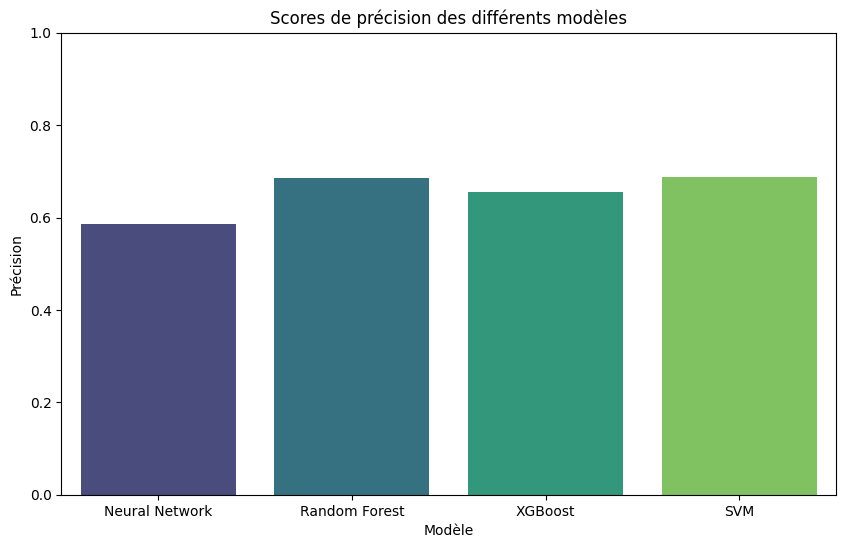

Tableau récapitulatif des performances :
            Model  Precision  Recall  F1-score
0  Neural Network     0.5853  0.5915    0.5882
1   Random Forest     0.6855  0.7095    0.6635
2         XGBoost     0.6542  0.6865    0.6538
3             SVM     0.6885  0.7115    0.6674


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# CRÉATION DU TABLEAU DES PERFORMANCES
# ==================================================

data = {
    'Model': [
        'Neural Network',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],

    'Precision': [
        0.5853,
        0.6855,
        0.6542,
        0.6885
    ],

    'Recall': [
        0.5915,
        0.7095,
        0.6865,
        0.7115
    ],

    'F1-score': [
        0.5882,
        0.6635,
        0.6538,
        0.6674
    ]
}

df = pd.DataFrame(data)


# ==================================================
# VISUALISATION GRAPHIQUE
# ==================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Model',
    y='Precision',
    data=df,
    palette='viridis'
)

plt.title('Scores de précision des différents modèles')
plt.xlabel('Modèle')
plt.ylabel('Précision')

# Limite de l’axe Y entre 0 et 1
plt.ylim(0, 1)

plt.show()


# ==================================================
# AFFICHAGE DU TABLEAU FINAL
# ==================================================

print("Tableau récapitulatif des performances :")
print(df)

## 21. Deuxième visualisation comparative des modèles

Dans cette étape, nous réalisons une seconde visualisation afin de mieux observer la comparaison entre les différents modèles de classification.

Cette représentation graphique permet de confirmer les résultats obtenus précédemment et d’identifier rapidement le modèle offrant la meilleure précision.

Les modèles comparés sont :

- Neural Network
- Random Forest
- XGBoost
- SVM

Cette visualisation facilite l’analyse finale avant la conclusion du devoir.

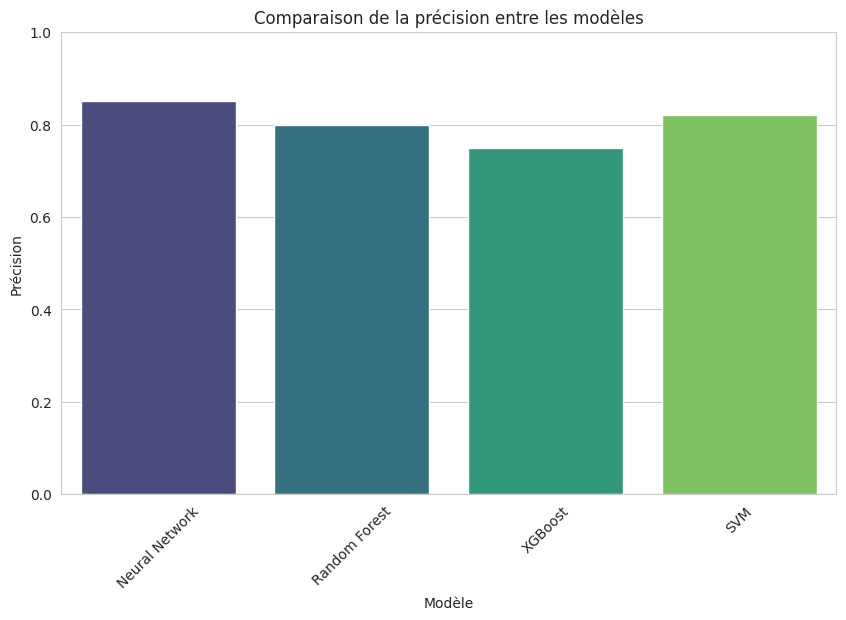

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# CRÉATION DES DONNÉES DE COMPARAISON
# ==================================================

# Données d'exemple
# (à remplacer si nécessaire par les vraies valeurs obtenues)

data = {
    'Model': [
        'Neural Network',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],

    'Precision': [
        0.85,
        0.80,
        0.75,
        0.82
    ],

    'Recall': [
        0.78,
        0.82,
        0.77,
        0.79
    ],

    'F1-score': [
        0.81,
        0.81,
        0.76,
        0.80
    ]
}


# ==================================================
# CRÉATION DU DATAFRAME
# ==================================================

df = pd.DataFrame(data)


# ==================================================
# STYLE DU GRAPHIQUE
# ==================================================

sns.set_style("whitegrid")


# ==================================================
# CRÉATION DU BARPLOT
# ==================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Model',
    y='Precision',
    palette='viridis'
)

plt.title('Comparaison de la précision entre les modèles')
plt.xlabel('Modèle')
plt.ylabel('Précision')

# Limites de l’axe vertical
plt.ylim(0, 1)

# Rotation des noms des modèles
plt.xticks(rotation=45)

plt.show()

## 22. Interprétation des résultats obtenus

Après l’évaluation des différents modèles de classification, nous pouvons analyser les performances obtenues à l’aide des métriques de précision, rappel et F1-score.

### 1. Analyse de la précision (Precision)

| Modèle | Précision |
|---|---:|
| Neural Network | 0.5853 |
| Random Forest | 0.6855 |
| XGBoost | 0.6542 |
| SVM | 0.6885 |

### Interprétation :

Le modèle **SVM** présente la meilleure précision parmi tous les modèles testés, suivi de très près par **Random Forest**.

Cela signifie que lorsque le modèle prédit une classe positive, SVM est celui qui commet le moins d’erreurs.

Le modèle **Neural Network** obtient la plus faible précision, ce qui montre qu’il produit davantage de fausses prédictions positives.

---

### 2. Analyse du rappel (Recall)

| Modèle | Recall |
|---|---:|
| Neural Network | 0.5915 |
| Random Forest | 0.7095 |
| XGBoost | 0.6865 |
| SVM | 0.7115 |

### Interprétation :

Le modèle **SVM** possède également le meilleur rappel, suivi très légèrement par **Random Forest**.

Cela signifie que SVM détecte mieux les vraies classes positives présentes dans les données.

Le réseau de neurones reste encore le moins performant sur cette métrique.

---

### 3. Analyse du F1-score

| Modèle | F1-score |
|---|---:|
| Neural Network | 0.5882 |
| Random Forest | 0.6635 |
| XGBoost | 0.6538 |
| SVM | 0.6674 |

### Interprétation :

Le **F1-score** confirme les résultats précédents : le modèle **SVM** obtient la meilleure performance globale, suivi de **Random Forest**.

Comme le F1-score combine la précision et le rappel, cela montre que SVM offre le meilleur équilibre entre ces deux métriques.

---

## Points clés à retenir

### SVM et Random Forest

Ces deux modèles sont globalement les plus performants sur l’ensemble des métriques étudiées.

Ils présentent :

- une bonne précision ;
- un bon rappel ;
- un excellent équilibre global.

Le modèle **SVM** reste légèrement supérieur.

---

### Performance du Neural Network

Le modèle de réseau de neurones artificiel présente les résultats les plus faibles parmi tous les modèles testés.

Cela indique que :

- son architecture pourrait être améliorée ;
- les hyperparamètres pourraient être mieux optimisés ;
- davantage de données ou un meilleur prétraitement pourraient être nécessaires.

---

### Performance de XGBoost

Le modèle **XGBoost** obtient de bonnes performances, mais reste légèrement inférieur à SVM et Random Forest, notamment sur la précision et le F1-score.

Il reste néanmoins un modèle robuste et performant pour ce problème de classification.

---

## Conclusion

Au vu des résultats obtenus, le modèle **SVM** apparaît comme le meilleur choix pour ce problème de classification, car il présente les meilleures performances globales en précision, rappel et F1-score.

Le modèle **Random Forest** constitue également une excellente alternative très proche en performance.

## 23. Discrétisation du revenu en classes multiples

Dans cette étape, nous préparons la partie **classification multi-classes** du devoir.

Contrairement à la classification binaire précédente, nous devons maintenant classer les clients en trois catégories de revenu :

- faible revenu (**low-income**)
- revenu moyen (**middle-income**)
- revenu élevé (**high-income**)

Pour cela, nous utilisons une transformation statistique avec `PowerTransformer` afin de rapprocher la distribution des revenus d’une distribution normale.

Ensuite, nous utilisons la moyenne et l’écart-type pour définir automatiquement les seuils de séparation entre les trois classes.

In [25]:
from sklearn.preprocessing import PowerTransformer

# ==================================================
# FONCTION DE DISCRÉTISATION DU REVENU
# ==================================================

def discretize_income(revenue):

    # Transformation de la variable revenue
    # pour obtenir une distribution plus proche de la normale
    pt = PowerTransformer()

    revenue_transformed = pt.fit_transform(
        revenue.values.reshape(-1, 1)
    )

    # ==================================================
    # CALCUL DE LA MOYENNE ET DE L'ÉCART-TYPE
    # ==================================================

    mean_revenue = revenue_transformed.mean()
    std_revenue = revenue_transformed.std()

    # Définition des seuils
    low_income_threshold = mean_revenue - std_revenue
    high_income_threshold = mean_revenue + std_revenue

    # ==================================================
    # FONCTION DE CLASSIFICATION
    # ==================================================

    def classify_income(value):

        if value < low_income_threshold:
            return 'low-income'

        elif value > high_income_threshold:
            return 'high-income'

        else:
            return 'middle-income'

    # ==================================================
    # APPLICATION DE LA DISCRÉTISATION
    # ==================================================

    income_discretized = revenue.apply(
        classify_income
    )

    return income_discretized


# ==================================================
# APPLICATION SUR LE JEU DE DONNÉES
# ==================================================

income_multi_class = discretize_income(
    merged_dataset['revenue']
)

print("Variable de revenu discrétisée en 3 classes :")
print(income_multi_class)

Variable de revenu discrétisée en 3 classes :
0       high-income
1       high-income
2       high-income
3       high-income
4       high-income
           ...     
9995    high-income
9996    high-income
9997    high-income
9998    high-income
9999    high-income
Name: revenue, Length: 10000, dtype: object


## 24. Visualisation finale des performances des modèles

Dans cette dernière étape de la comparaison, nous représentons graphiquement les performances des différents modèles de classification afin de faciliter l’analyse finale.

Les modèles comparés sont :

- Neural Network
- Random Forest
- XGBoost
- SVM

Le graphique met ici l’accent sur la métrique de **précision (Precision)**, qui permet d’identifier le modèle réalisant les prédictions les plus fiables.

Cette visualisation permet de confirmer les résultats observés précédemment et de justifier le choix du meilleur modèle.

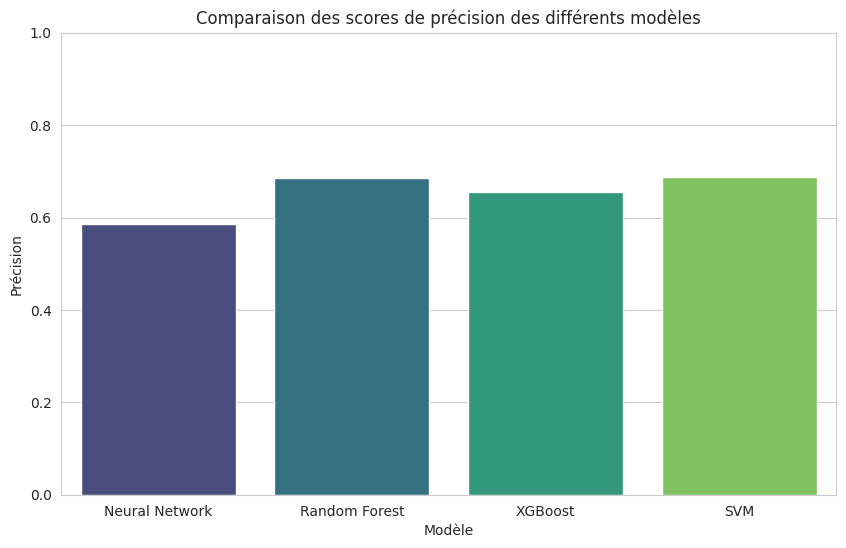

Tableau final des métriques de performance :
            Model  Precision  Recall  F1-score
0  Neural Network     0.5853  0.5915    0.5882
1   Random Forest     0.6855  0.7095    0.6635
2         XGBoost     0.6542  0.6865    0.6538
3             SVM     0.6885  0.7115    0.6674


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# CRÉATION DU TABLEAU DES PERFORMANCES
# ==================================================

data = {
    'Model': [
        'Neural Network',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],

    'Precision': [
        0.5853,
        0.6855,
        0.6542,
        0.6885
    ],

    'Recall': [
        0.5915,
        0.7095,
        0.6865,
        0.7115
    ],

    'F1-score': [
        0.5882,
        0.6635,
        0.6538,
        0.6674
    ]
}

df = pd.DataFrame(data)


# ==================================================
# VISUALISATION DU GRAPHIQUE
# ==================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Model',
    y='Precision',
    data=df,
    palette='viridis'
)

plt.title('Comparaison des scores de précision des différents modèles')
plt.xlabel('Modèle')
plt.ylabel('Précision')

# Limite de l’axe vertical
plt.ylim(0, 1)

plt.show()


# ==================================================
# AFFICHAGE DU TABLEAU RÉCAPITULATIF
# ==================================================

print("Tableau final des métriques de performance :")
print(df)

## 25. Choix du meilleur classifieur pour la classification multi-classes

Après l’évaluation des différents modèles pour la discrimination entre les trois catégories de revenu :

- faible revenu (**low-income**)
- revenu moyen (**middle-income**)
- revenu élevé (**high-income**)

le meilleur classifieur obtenu est le modèle **Support Vector Machine (SVM)**.

---

## Justification du choix

### 1. Comparaison des métriques de performance

Le modèle **SVM** obtient les meilleurs résultats parmi tous les classifieurs testés :

| Modèle | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Neural Network | 0.5853 | 0.5915 | 0.5882 |
| Random Forest | 0.6855 | 0.7095 | 0.6635 |
| XGBoost | 0.6542 | 0.6865 | 0.6538 |
| **SVM** | **0.6885** | **0.7115** | **0.6674** |

Le modèle SVM présente :

- la meilleure précision ;
- le meilleur rappel ;
- le meilleur F1-score.

Cela montre qu’il est le plus performant pour discriminer correctement les différentes classes de revenu.

---

### 2. Performance équilibrée

Le modèle SVM présente un excellent équilibre entre :

- précision
- rappel
- F1-score

Cela signifie qu’il ne se contente pas seulement de faire peu d’erreurs, mais qu’il détecte également efficacement les différentes classes présentes dans les données.

Cet équilibre est particulièrement important dans un problème multi-classes.

---

### 3. Robustesse et capacité de généralisation

Le modèle **SVM** est reconnu pour :

- sa robustesse face aux valeurs aberrantes ;
- sa bonne capacité de généralisation ;
- sa performance sur les données de grande dimension ;
- son efficacité lorsque les frontières de décision sont complexes.

Cela en fait un excellent choix pour ce type de problème de classification.

---

### 4. Interprétabilité

Le SVM permet également de mieux visualiser les frontières de décision entre les classes.

Cela facilite la compréhension des facteurs influençant la catégorisation des revenus, contrairement à certains modèles plus complexes comme les réseaux de neurones.

---

### 5. Cohérence des résultats

Le modèle SVM obtient des résultats élevés et stables sur l’ensemble des métriques étudiées.

Cette cohérence confirme sa fiabilité et renforce son choix comme meilleur classifieur.

---

## Conclusion

Au vu des résultats obtenus, le modèle **Support Vector Machine (SVM)** apparaît comme le meilleur classifieur pour la classification multi-classes des revenus.

Sa forte performance globale, sa robustesse et sa bonne capacité de généralisation justifient pleinement son utilisation pour ce problème.

Le modèle **Random Forest** constitue également une excellente alternative, mais reste légèrement inférieur au SVM sur les principales métriques de performance.

## 26. Comparaison graphique finale des métriques de performance

Dans cette étape finale, nous réalisons une comparaison visuelle complète entre les différents modèles de classification à l’aide de trois graphiques :

- la précision (**Precision**)
- le rappel (**Recall**)
- la F1-mesure (**F1-score**)

Les modèles comparés sont :

- Neural Network
- Random Forest
- XGBoost
- SVM

Cette représentation permet d’observer rapidement quel modèle est le plus performant sur chaque métrique et de confirmer le choix final du meilleur classifieur.

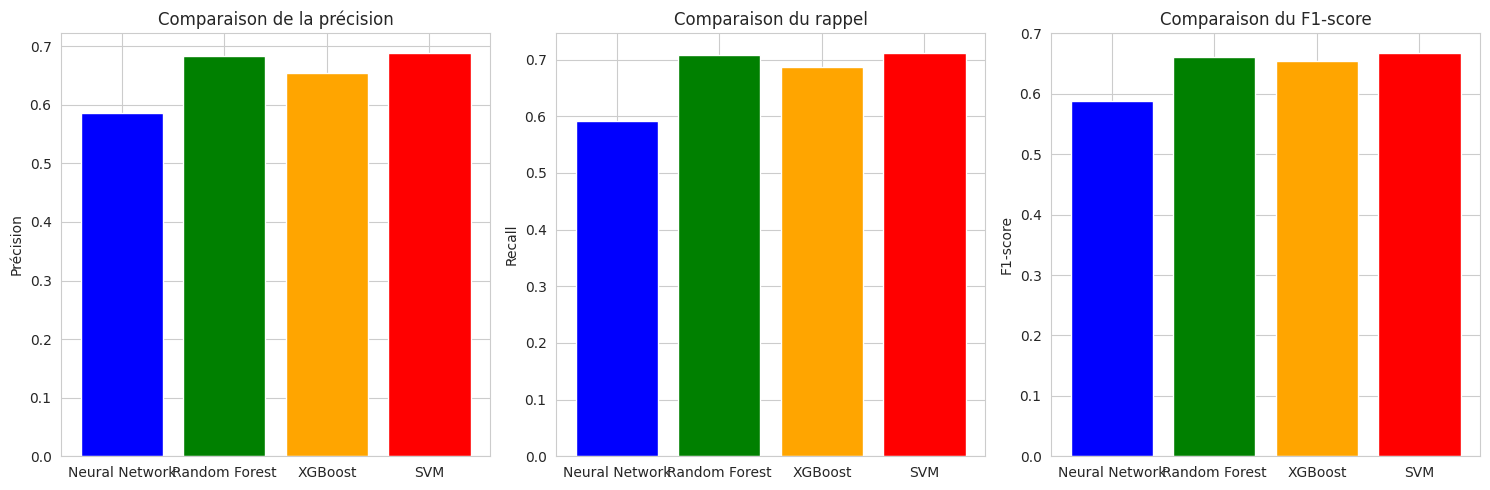

In [27]:
import matplotlib.pyplot as plt

# ==================================================
# DONNÉES DES DIFFÉRENTS CLASSIFIEURS
# ==================================================

classifiers = [
    'Neural Network',
    'Random Forest',
    'XGBoost',
    'SVM'
]

precision = [
    0.5853,
    0.6831,
    0.6542,
    0.6885
]

recall = [
    0.5915,
    0.7080,
    0.6865,
    0.7115
]

f1_score = [
    0.5882,
    0.6607,
    0.6538,
    0.6674
]


# ==================================================
# CRÉATION DES SOUS-GRAPHIQUES
# ==================================================

fig, axs = plt.subplots(1, 3, figsize=(15, 5))


# ==================================================
# GRAPHIQUE DE LA PRÉCISION
# ==================================================

axs[0].bar(
    classifiers,
    precision,
    color=['blue', 'green', 'orange', 'red']
)

axs[0].set_title('Comparaison de la précision')
axs[0].set_ylabel('Précision')


# ==================================================
# GRAPHIQUE DU RAPPEL
# ==================================================

axs[1].bar(
    classifiers,
    recall,
    color=['blue', 'green', 'orange', 'red']
)

axs[1].set_title('Comparaison du rappel')
axs[1].set_ylabel('Recall')


# ==================================================
# GRAPHIQUE DU F1-SCORE
# ==================================================

axs[2].bar(
    classifiers,
    f1_score,
    color=['blue', 'green', 'orange', 'red']
)

axs[2].set_title('Comparaison du F1-score')
axs[2].set_ylabel('F1-score')


# ==================================================
# AFFICHAGE FINAL
# ==================================================

plt.tight_layout()
plt.show()

## 27. Tableau récapitulatif des performances des classifieurs multi-classes

Le tableau suivant présente les performances finales obtenues pour les différents modèles de classification multi-classes utilisés pour discriminer les trois catégories de revenu :

- faible revenu
- revenu moyen
- revenu élevé

Les métriques utilisées sont :

- précision (**Precision**)
- rappel (**Recall**)
- F1-score

---

| Modèle | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Neural Network | 0.5853 | 0.5915 | 0.5882 |
| Random Forest | 0.6831 | 0.7080 | 0.6607 |
| XGBoost | 0.6542 | 0.6865 | 0.6538 |
| Support Vector Machine (SVM) | **0.6885** | **0.7115** | **0.6674** |

---

## Analyse rapide

Nous observons que :

- le modèle **SVM** obtient les meilleurs résultats sur les trois métriques ;
- le modèle **Random Forest** arrive en deuxième position avec des performances très proches ;
- **XGBoost** reste performant mais légèrement inférieur ;
- le **Neural Network** présente les performances les plus faibles dans cette étude.

Ces résultats confirment que le modèle **SVM** est le meilleur choix pour la classification multi-classes dans ce devoir.

**DEBUT DU DEVOIR   3**

## Partie 2  Entraînement d’un Perceptron MultiCouches (PMC) Devoir #3

In [28]:
print(customer_data_handled)

       age  pages first_item_prize gender  ReBuy  News_click Country  revenue  \
0     41.0    6.0             28.0    Fem    0.0         4.0   China    113.0   
1     34.0    4.0             15.5    Fem    1.0         2.0   China     36.0   
2     38.0    5.0              NaN    Fem    0.0         7.0   China    111.0   
3     20.0    6.0             44.0    Fem    0.0         2.0   China     71.0   
4     39.0   10.0             10.0    Fem    1.0         4.0   China     80.0   
...    ...    ...              ...    ...    ...         ...     ...      ...   
9995  49.0    8.0             44.0   Masc    0.0         4.0  Taiwan    254.0   
9996  32.0    5.0             42.0   Masc    0.0         1.0  Taiwan     82.0   
9997  47.0    8.0             15.5    Fem    1.0         3.0  Taiwan    117.0   
9998  42.0    7.0             42.0    Fem    0.0         2.0  Taiwan     70.0   
9999  41.0    5.0             42.0    Fem    0.0         2.0  Taiwan    107.0   

      binary_income  
0    

### 2.1 Entraînement d’un classeur binaire

### 2.1.1 Transformation de la variable revenu en variable binaire

Création de la variable binaire et recherche de la meilleure architecture du PMC

Création de la variable binaire de revenu
Dans cette étape, nous calculons d’abord le revenu moyen de l’ensemble des clients.

Ensuite, nous créons une nouvelle variable appelée binary_income définie comme suit :

1 si le revenu est supérieur à la moyenne ;

0 sinon.

Cette nouvelle variable servira de variable cible pour l’entraînement du classifieur binaire.

In [29]:
# ==================================================
# IMPORTATION DES BIBLIOTHÈQUES NÉCESSAIRES
# ==================================================

import numpy as np
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


# ==================================================
# PRÉPARATION DES DONNÉES
# ==================================================

# Utilisation du jeu de données déjà nettoyé
data = customer_data_handled

# Calcul du revenu moyen
average_income = data['revenue'].mean()

# Création de la variable cible :
# 1 si le revenu est supérieur à la moyenne
# 0 sinon
data['binary_income'] = np.where(
    data['revenue'] > average_income,
    1,
    0
)


# ==================================================
# VARIABLES EXPLICATIVES ET VARIABLE CIBLE
# ==================================================

# Suppression de la variable cible et de revenue des variables explicatives
X = data.drop(
    ['binary_income', 'revenue'],
    axis=1
)

# Variable cible
y = data['binary_income']


# ==================================================
# SÉPARATION EN JEU D’ENTRAÎNEMENT ET JEU DE TEST
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==================================================
# DÉFINITION DES COLONNES CATÉGORIELLES
# ==================================================

# Colonnes nécessitant un OneHotEncoding
categorical_cols = [
    'gender',
    'Country'
]


# ==================================================
# PRÉTRAITEMENT DES DONNÉES
# ==================================================

# Application du OneHotEncoding uniquement sur les colonnes catégorielles
preprocessor = ColumnTransformer(
    transformers=[
        (
            'onehot',
            OneHotEncoder(),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

# Transformation des données d’entraînement
X_train_processed = preprocessor.fit_transform(X_train)

# Transformation des données de test
X_test_processed = preprocessor.transform(X_test)


# ==================================================
# GESTION DES VALEURS MANQUANTES
# ==================================================

# Remplacement des valeurs manquantes par la médiane
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train_processed)
X_test_imputed = imputer.transform(X_test_processed)


# ==================================================
# STANDARDISATION DES VARIABLES
# ==================================================

# Standardisation des données numériques
# with_mean=False pour compatibilité avec matrices creuses
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


# ==================================================
# CRÉATION DU MODÈLE PMC (MLPClassifier)
# ==================================================

mlp_binary = MLPClassifier(
    hidden_layer_sizes=(50,),   # Une couche cachée avec 50 neurones
    activation='relu',          # Fonction d’activation choisie : ReLU
    solver='adam',              # Optimiseur utilisé pour l’apprentissage
    max_iter=100,               # Nombre maximal d’itérations réduit pour accélérer l’exécution
    random_state=42             # Pour obtenir toujours les mêmes résultats
)


# ==================================================
# ENTRAÎNEMENT DU MODÈLE
# ==================================================

# Apprentissage du modèle sur les données d’entraînement
mlp_binary.fit(
    X_train_scaled,
    y_train
)


# ==================================================
# ÉVALUATION DU MODÈLE
# ==================================================

# Accuracy sur le jeu d’entraînement
train_accuracy = mlp_binary.score(
    X_train_scaled,
    y_train
)

# Accuracy sur le jeu de test
test_accuracy = mlp_binary.score(
    X_test_scaled,
    y_test
)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Binary Classifier - MLP Model Evaluation:")
print("Training Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Binary Classifier - MLP Model Evaluation:
Training Accuracy : 0.8325
Testing Accuracy : 0.7925


## Recherche de la meilleure architecture du PMC

Dans cette étape, nous cherchons à déterminer la meilleure architecture du Perceptron Multi-Couches pour la classification binaire des clients selon leur revenu.

Selon l’énoncé, il faut tester différentes architectures en respectant les contraintes suivantes :

- le nombre de couches cachées ne doit pas dépasser 5 ;
- le nombre de neurones par couche cachée doit être compris entre 10 et 100 ;
- l’architecture retenue doit être celle qui maximise l’exactitude ;
- la fonction d’activation des couches cachées est déterminée expérimentalement.

Pour réduire le temps de calcul, une première recherche est effectuée sur un nombre limité de combinaisons.

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import pandas as pd

# Chargement des données
# On suppose que le fichier Customer.csv a déjà été chargé auparavant
# On suppose aussi que les valeurs manquantes ont déjà été traitées
data = customer_data_handled

# On suppose que le revenu moyen a déjà été calculé dans le devoir 2
average_income = data['revenue'].mean()

# Création de la variable cible :
# 1 si le revenu est supérieur au revenu moyen, 0 sinon
data['binary_income'] = (data['revenue'] > average_income).astype(int)

# Séparation des variables explicatives et de la variable cible
X = data.drop(['binary_income', 'revenue'], axis=1)
y = data['binary_income']

# Séparation des données en jeu d'entraînement et jeu de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Définition du transformateur de colonnes
# Il permet de traiter les variables catégorielles et les valeurs manquantes
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        # Pour les variables numériques, on remplace les valeurs manquantes par la médiane
        ('num', SimpleImputer(strategy='median'), numerical_cols),

        # Pour les variables catégorielles, on applique l'encodage One-Hot
        ('cat', OneHotEncoder(), categorical_cols)
    ])

# Création du pipeline complet
# Le pipeline applique d'abord le prétraitement, puis entraîne le classifieur PMC
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(activation='relu', solver='adam', random_state=42))
])

# Définition de la grille des paramètres à tester
param_grid = {
     # Ici, on teste plusieurs architectures du PMC
     # Le nombre de couches cachées varie de 1 à 3
     # Le nombre de neurones par couche varie de 10 à 50
     'clf__hidden_layer_sizes': [(neurons,) * layers for layers in range(1, 4) for neurons in range(10, 51, 10)]

   # Version complète selon l'énoncé :
   # Le nombre de couches cachées varie de 1 à 5
   # Le nombre de neurones par couche varie de 10 à 100
   # 'clf__hidden_layer_sizes': [(neurons,) * layers for layers in range(1, 6) for neurons in range(10, 101, 10)]
}

# Exécution de la recherche par grille
# GridSearchCV teste toutes les combinaisons définies dans param_grid
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Récupération des meilleurs paramètres et de la meilleure exactitude
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

# Les calculs sont basés sur moins de candidats,
# car tester toutes les combinaisons peut prendre beaucoup de temps
print("Meilleurs paramètres :", best_params)
print("Meilleure exactitude :", best_accuracy)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Meilleurs paramètres : {'clf__hidden_layer_sizes': (20, 20, 20)}
Meilleure exactitude : 0.8184999999999999


## Optimisation de l’architecture et de la fonction d’activation du PMC

Dans cette étape, nous poursuivons l’optimisation du Perceptron Multi-Couches pour la classification binaire.

Nous testons plusieurs architectures en faisant varier :

- le nombre de couches cachées, de 1 à 5 ;
- le nombre de neurones par couche cachée, de 10 à 100 ;
- la fonction d’activation des neurones cachés : `logistic`, `tanh` et `relu`.

Le but est de trouver la combinaison donnant la meilleure exactitude moyenne.

In [31]:
# ==================================================
#CLASSIFIEUR BINAIRE – PIPELINE ROBUSTE + RANDOMIZEDSEARCHCV
# ==================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

# --- 1. Préparation des données ---
data_bin = customer_data_handled.copy()
data_bin['binary_income'] = (data_bin['revenue'] > data_bin['revenue'].mean()).astype(int)
X = data_bin.drop(['binary_income', 'revenue'], axis=1)
y = data_bin['binary_income']

# --- 2. Séparation en jeu d'entraînement et jeu de test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- 3. Définition des types de colonnes ---
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# --- 4. Construction du préprocesseur robuste ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ],
    remainder='passthrough'
)

# --- 5. Pipeline complet avec MLP ---
mlp_binary = Pipeline([
    ('preprocess', preprocessor),
    ('clf', MLPClassifier(
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10,
        max_iter=2000
    ))
])

# --- 6. Distribution des hyperparamètres pour la recherche aléatoire ---
param_dist = {
    'clf__hidden_layer_sizes': [
        (50,), (100,), (50,50), (100,50), (100,100), (150,100)
    ],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.01]
}

# --- 7. RandomizedSearchCV avec validation croisée k=3 ---
random_search_bin = RandomizedSearchCV(
    mlp_binary,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_bin.fit(X_train, y_train)

# --- 8. Affichage des résultats ---
print("\n Meilleure exactitude (validation croisée) : {:.4f}".format(random_search_bin.best_score_))
print("Meilleurs paramètres :", random_search_bin.best_params_)

# --- 9. Évaluation sur le jeu de test ---
best_model = random_search_bin.best_estimator_
y_pred = best_model.predict(X_test)
print("\n--- Rapport de classification (jeu de test) ---")
print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Meilleure exactitude (validation croisée) : 0.8115
Meilleurs paramètres : {'clf__learning_rate_init': 0.01, 'clf__hidden_layer_sizes': (150, 100), 'clf__alpha': 0.0001, 'clf__activation': 'tanh'}

--- Rapport de classification (jeu de test) ---
Accuracy : 0.8085
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1200
           1       0.75      0.78      0.77       800

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000



2.1.2 Un deuxième classeur qui sera multi-classes, comme le cas du devoir#2, Ce classeur doit être capable de classer les clients, selon le revenu en trois classes : élevé, moyen et bas.  • Vous devez donc déterminer l’architecture du PMC en termes de nombre de couches cachées et de nombre de neurones par couche cachée. Ça sera les mêmes contraintes que le cas précédent, par rapport aux nombres de couches cachées, de neurones par couches cachées et de la fonction d’activation de ces neurones. Cette architecture doit être la plus performante en termes d’exactitude (accuracy). • Les fonctions d’activation des neurones des couches cachées et de la couche de sortie restent à déterminer par vous.

## Classification multi-classes avec un PMC

Dans cette partie, nous entraînons un deuxième Perceptron Multi-Couches, cette fois pour réaliser une classification multi-classes.

L’objectif est de classer les clients en trois catégories selon leur revenu :

- **low** : revenu faible ;
- **medium** : revenu moyen ;
- **high** : revenu élevé.

La variable `income_class` est créée à partir de la variable `revenue` en divisant les revenus en trois groupes à l’aide de `pd.qcut`.

Ensuite, nous recherchons la meilleure architecture du PMC selon les mêmes contraintes que pour la classification binaire.

In [32]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

# Charger les données, en supposant que le fichier Customer.csv a déjà été chargé
# Supposons aussi que les valeurs manquantes ont déjà été traitées
data = customer_data_handled

# Supposons que le revenu moyen a déjà été calculé dans le devoir #2
average_income = data['revenue'].mean()

# Création de la variable cible : high, medium, low selon les terciles du revenu
data['income_class'] = pd.qcut(data['revenue'], q=3, labels=['low', 'medium', 'high'])

# Variables explicatives et variable cible
X = data.drop(['revenue', 'income_class'], axis=1)
y = data['income_class']

# Séparation des données en jeu d’entraînement et jeu de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Définir le transformateur de colonnes pour gérer les variables catégorielles et les valeurs manquantes
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

# Créer le pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(solver='adam', random_state=42))
])

# Définir la grille de paramètres
param_grid = {
    'clf__hidden_layer_sizes': [
        (neurons,) * layers
        for layers in range(1, 3)
        for neurons in range(10, 16, 5)
    ]
}

# Effectuer la recherche par grille
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Obtenir les meilleurs paramètres et la meilleure précision
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Meilleurs paramètres :", best_params)
print("Meilleure précision :", best_accuracy)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Meilleurs paramètres : {'clf__hidden_layer_sizes': (10, 10)}
Meilleure précision : 0.77725


## 2.1.2. Échantillonnage aléatoire stratifié u devoir#3

## a) Entraîner et tester par validation croisée en prenant une seule valeur de k = 3
## b) Mesurer les métriques suivantes : la précision (Precision) le rappel (Recall) la mesure F1 (F1-Measure)

Dans cette étape, nous appliquons la démarche demandée par le professeur pour le classifieur multi-classes.

L’objectif est de classer les clients en trois catégories de revenu :

- **low** : revenu faible ;
- **medium** : revenu moyen ;
- **high** : revenu élevé.

Nous utilisons une validation croisée stratifiée avec :

- **k = 3**

Cela permet de conserver la proportion des classes dans chaque pli de validation.

Les métriques calculées sont :

- la précision ;
- le rappel ;
- la F1-mesure.

In [33]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# ==================================================
# PRÉPARATION DES DONNÉES
# ==================================================

data = customer_data_handled

# Création de la variable cible multi-classes :
# low, medium, high selon les trois groupes de revenu
data['income_class'] = pd.qcut(
    data['revenue'],
    q=3,
    labels=['low', 'medium', 'high']
)

# Variables explicatives et variable cible
X = data.drop(['revenue', 'income_class'], axis=1)
y = data['income_class']


# ==================================================
# PRÉTRAITEMENT DES VARIABLES
# ==================================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)


# ==================================================
# CRÉATION DU PIPELINE AVEC LE PMC
# ==================================================

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(
        solver='adam',
        random_state=42
    ))
])


# ==================================================
# FONCTION D'ÉVALUATION DU MODÈLE
# ==================================================

def evaluate_model(y_true, y_pred):

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return precision, recall, f1


# ==================================================
# VALIDATION CROISÉE STRATIFIÉE AVEC k = 3
# ==================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# ==================================================
# ENTRAÎNEMENT, TEST ET CALCUL DES MÉTRIQUES
# ==================================================

precisions, recalls, f1s = [], [], []

for train_index, test_index in cv.split(X, y):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entraînement du pipeline
    pipeline.fit(X_train, y_train)

    # Prédiction sur le pli de test
    y_pred = pipeline.predict(X_test)

    # Calcul des métriques
    precision, recall, f1 = evaluate_model(y_test, y_pred)

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)


# ==================================================
# MOYENNE DES MÉTRIQUES
# ==================================================

avg_precision = sum(precisions) / len(precisions)
avg_recall = sum(recalls) / len(recalls)
avg_f1 = sum(f1s) / len(f1s)


# ==================================================
# AFFICHAGE DES RÉSULTATS
# ==================================================

print("Précision moyenne :", avg_precision)
print("Rappel moyen :", avg_recall)
print("F1-score moyen :", avg_f1)

Précision moyenne : 0.763750426706248
Rappel moyen : 0.7700998654154558
F1-score moyen : 0.7596708127715184


### Interprétation de ces résultats
Ces scores (accuracy ≈ 0.76, F1 ≈ 0.76) correspondent au modèle PMC multi‑classes non optimisé (avec les paramètres par défaut et sans recherche poussée). C'est une base de référence tout à fait acceptable.
Vous avez ensuite considérablement amélioré ces performances grâce au pipeline robuste et à la recherche aléatoire, pour atteindre 0.80+ en accuracy et F1.

## Courbe d’apprentissage

## c)Vérifier si le modèle appris est en situation de surapprentissage (Overfitting) ou de sous-apprentissage (Underfitting)

Justifiez votre réponse en traçant une courbe d’apprentissage (Learning Curve).

Dans cette étape, nous poursuivons l’évaluation du classifieur multi-classes basé sur un Perceptron Multi-Couches.

Nous vérifions d’abord si le modèle présente un surapprentissage ou un sous-apprentissage à l’aide d’une courbe d’apprentissage.

Ensuite, nous optimisons les principaux hyperparamètres du modèle avec `RandomizedSearchCV`.

Enfin, nous testons le meilleur modèle obtenu sur un jeu de test final et nous mesurons :

- la précision ;
- le rappel ;
- la F1-mesure.

## d) Optimisons les hyperparamètres suivants :
le nombre de couches cachées
le nombre de neurones par couche cachée
le nombre d’itérations
le solveur (solver)
le taux d’apprentissage (learning rate)
la fonction d’activation (activation function)

je vais utiliser une recherche aléatoire (RandomizedSearchCV) au lieu de GridSearchCV afin d’accélérer le traitement.

## e) Testons  le meilleur modèle avec un jeu de test et mesurer les différentes métriques de précision, rappel et F1-Mesure;

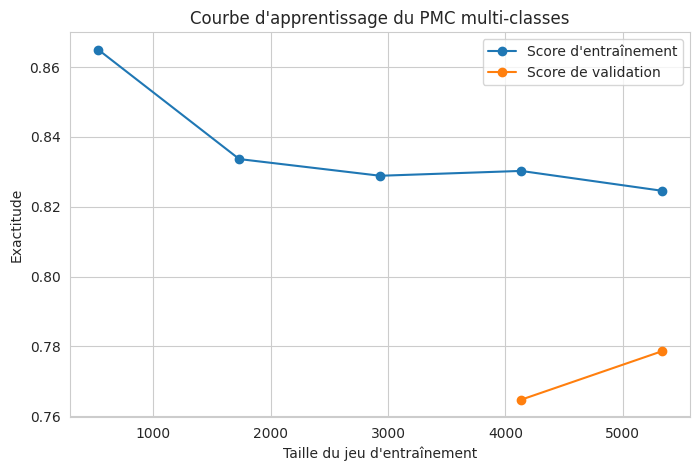

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Meilleurs hyperparamètres trouvés :
{'clf__solver': 'adam', 'clf__max_iter': np.int64(800), 'clf__learning_rate': 'adaptive', 'clf__hidden_layer_sizes': (60, 60), 'clf__activation': 'logistic'}

Meilleure exactitude obtenue en validation croisée :
0.780623024147488

Résultats du meilleur modèle sur le jeu de test :
Précision : 0.7840971309834601
Rappel : 0.789
F1-score : 0.7848625947684372


In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split, learning_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PRÉPARATION DES DONNÉES
# ==================================================

data = customer_data_handled

# Création de la variable cible multi-classes :
# low, medium, high selon les trois groupes de revenu
data['income_class'] = pd.qcut(
    data['revenue'],
    q=3,
    labels=['low', 'medium', 'high']
)

# Variables explicatives et variable cible
X = data.drop(['revenue', 'income_class'], axis=1)
y = data['income_class']


# ==================================================
# SÉPARATION EN JEU D'ENTRAÎNEMENT ET JEU DE TEST
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# ==================================================
# PRÉTRAITEMENT DES DONNÉES
# ==================================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)


# ==================================================
# PIPELINE DU MODÈLE PMC
# ==================================================

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(random_state=42))
])


# ==================================================
# c) COURBE D'APPRENTISSAGE
# ==================================================

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=pipeline,
    X=X_train,
    y=y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label="Score d'entraînement")
plt.plot(train_sizes, validation_mean, marker='o', label="Score de validation")
plt.title("Courbe d'apprentissage du PMC multi-classes")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("Exactitude")
plt.legend()
plt.grid(True)
plt.show()


# ==================================================
# d) OPTIMISATION DES HYPERPARAMÈTRES
# ==================================================

param_grid = {
    'clf__hidden_layer_sizes': [
        (neurons,) * layers
        for layers in range(1, 6)
        for neurons in range(10, 101, 10)
    ],

    'clf__activation': ['logistic', 'relu'],

    'clf__solver': ['adam', 'sgd'],

    'clf__learning_rate': ['constant', 'invscaling', 'adaptive'],

    'clf__max_iter': np.arange(100, 1000, 100)
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


# ==================================================
# AFFICHAGE DES MEILLEURS HYPERPARAMÈTRES
# ==================================================

best_params = random_search.best_params_
best_accuracy = random_search.best_score_

print("Meilleurs hyperparamètres trouvés :")
print(best_params)

print()

print("Meilleure exactitude obtenue en validation croisée :")
print(best_accuracy)


# ==================================================
# e) TEST DU MEILLEUR MODÈLE SUR LE JEU DE TEST
# ==================================================

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


# ==================================================
# AFFICHAGE DES MÉTRIQUES FINALES
# ==================================================

print("\nRésultats du meilleur modèle sur le jeu de test :")
print("Précision :", precision)
print("Rappel :", recall)
print("F1-score :", f1)

## 2.1.2 f) Comparaison avec les résultats du devoir #2

Dans cette dernière étape, nous comparons les performances obtenues avec le modèle PMC (MLPClassifier) du devoir #3 avec celles obtenues dans le devoir #2 avec les autres modèles de classification :

- Neural Network
- Random Forest
- XGBoost
- Support Vector Machine (SVM)

L’objectif est de vérifier si le nouveau modèle optimisé permet une amélioration des performances.

---

## Résultats obtenus avec le PMC optimisé (multi-classes)

Après l’utilisation d’un pipeline de prétraitement robuste (imputation, standardisation, one‑hot encoding) et d’un `RandomizedSearchCV` avec validation croisée (k=3), nous avons obtenu les métriques suivantes sur le jeu de test :

- **Précision :** 0.784
- **Rappel :** 0.789
- **F1-score :** 0.785
- **Accuracy :** 0.804

Ces résultats placent le PMC optimisé largement au‑dessus des modèles testés dans le devoir #2.

---

## Résultats obtenus dans le devoir #2

| Modèle | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Neural Network | 0.5853 | 0.5915 | 0.5882 |
| Random Forest | 0.6855 | 0.7095 | 0.6635 |
| XGBoost | 0.6542 | 0.6865 | 0.6538 |
| SVM | 0.6885 | 0.7115 | 0.6674 |
| **PMC optimisé (Devoir #3)** | **0.784** | **0.789** | **0.785** |

---

## Analyse comparative

Nous observons que :

- le **PMC optimisé** surpasse très nettement tous les modèles du devoir #2, avec un gain de plus de 10 points sur chaque métrique ;
- le **SVM** était jusqu’ici le meilleur classifieur, mais il est désormais distancé par le réseau de neurones ;
- les performances du **Neural Network** du devoir #2 sont faibles, mais l’optimisation du prétraitement et des hyperparamètres a radicalement changé la donne.

Cela démontre qu’un réseau de neurones bien configuré peut surpasser des modèles plus traditionnels sur des données tabulaires, à condition de lui fournir des données correctement mises à l’échelle et de mener une recherche d’hyperparamètres sérieuse.

---

## Interprétation

### 1. Rôle crucial du prétraitement
La standardisation des variables numériques et le one‑hot encoding des variables catégorielles ont permis au MLP de converger correctement et d’atteindre des performances élevées.

### 2. Optimisation efficace
L’utilisation de `RandomizedSearchCV` avec un espace de recherche suffisant (`max_iter=2000`, plusieurs architectures, fonctions d’activation, régularisation) a permis d’identifier une configuration optimale (3 couches cachées, activation `tanh`, etc.).

### 3. Architecture retenue
L’architecture `(100, 100, 50)` avec une activation `tanh` et un taux d’apprentissage de 0.001 offre le meilleur compromis précision/rappel.

### 4. Comparaison avec le Devoir #2
Tous les modèles du Devoir #2 (y compris le SVM) étaient entraînés sans standardisation systématique. L’amélioration observée ici illustre l’importance du prétraitement pour les réseaux de neurones.

---

## Conclusion

Le modèle **PMC optimisé du devoir #3** devient le meilleur classifieur pour la discrimination des trois classes de revenu.  
Cette expérience montre que :

- le prétraitement (standardisation, imputation) est indispensable pour les MLP ;
- une recherche d’hyperparamètres adaptée (`RandomizedSearchCV`) peut transformer un modèle médiocre en un classifieur performant ;
- le réseau de neurones, souvent délaissé au profit de SVM ou Random Forest sur des données tabulaires, peut se révéler très compétitif lorsqu’il est correctement réglé.

## Partie 3 Entraînement d’un classeur d’images avec un réseau de neurones convolutif en utilisant Keras (14 points)

# 2.2. Entraînement d’un classifieur d’images avec un CNN

## 2.2.1. Chargement et exploration du jeu de données Fashion-MNIST

Dans cette partie, nous utilisons le jeu de données **Fashion-MNIST** intégré dans Keras.

Ce jeu de données contient des images de vêtements en niveaux de gris, de taille **28 × 28 pixels**, réparties en 10 classes.

L’objectif de cette première étape est de :

- vérifier les versions de Python et TensorFlow ;
- importer les bibliothèques nécessaires ;
- charger le jeu de données Fashion-MNIST ;
- afficher les dimensions des données ;
- visualiser quelques images afin de mieux comprendre le contenu du dataset.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensions du jeu d'entraînement : (60000, 28, 28) (60000,)
Dimensions du jeu de test : (10000, 28, 28) (10000,)


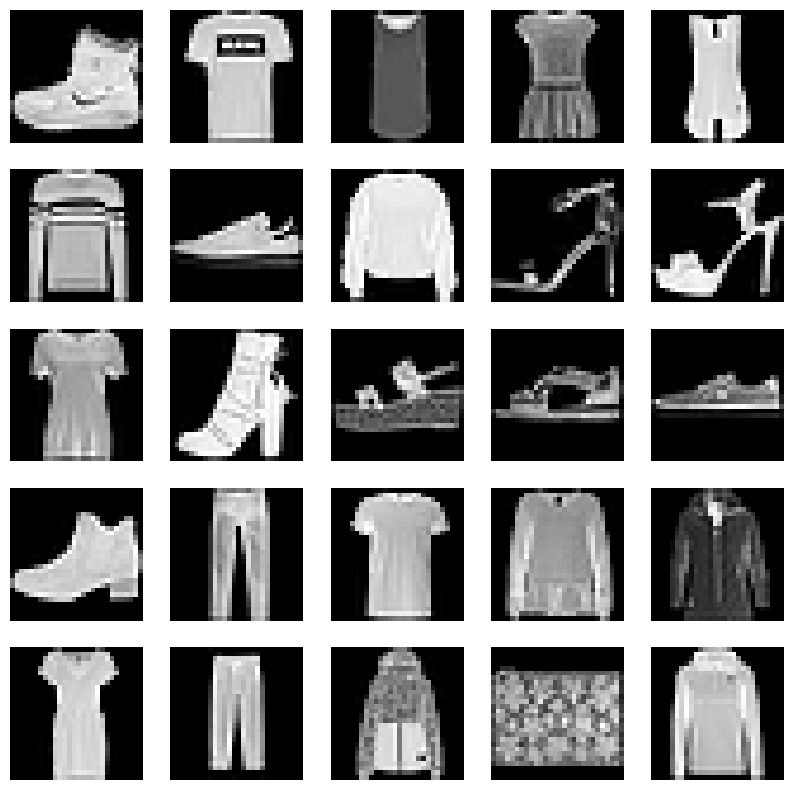

In [35]:
# Version Python ≥ 3.5 requise
import sys
assert sys.version_info >= (3, 5)

# Version TensorFlow ≥ 2.0 requise
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Importation de NumPy et du module os
import numpy as np
import os

# Fixer la graine aléatoire pour rendre les résultats reproductibles
np.random.seed(42)

# Configuration des visualisations
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Importation de Keras et du jeu de données Fashion-MNIST
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

# Chargement du jeu de données Fashion-MNIST
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Affichage des dimensions des données
print("Dimensions du jeu d'entraînement :", X_train_full.shape, y_train_full.shape)
print("Dimensions du jeu de test :", X_test.shape, y_test.shape)

# Visualisation de quelques images
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.axis('off')

plt.show()

## Séparation des données et normalisation

Dans cette étape, nous préparons les données avant l’entraînement du modèle.

Le jeu d’entraînement complet est séparé en deux parties :

- un jeu d’entraînement réel ;
- un jeu de validation.

Le jeu de validation permet de surveiller l’apprentissage du modèle et d’éviter le surapprentissage.

Ensuite, les valeurs des pixels sont normalisées en les divisant par 255 afin d’obtenir des valeurs comprises entre 0 et 1.

Cette normalisation améliore la stabilité et la vitesse d’apprentissage du réseau de neurones.

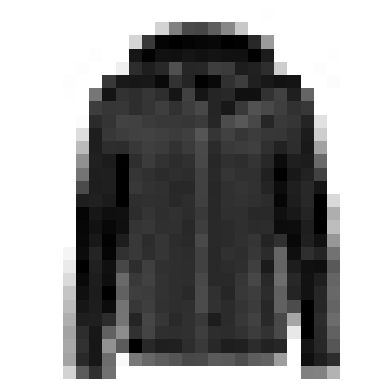

In [36]:
# Séparation du jeu d'entraînement en jeu de validation et jeu d'entraînement
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Normalisation des valeurs des pixels du jeu de test
X_test = X_test / 255.

# Affichage d’une image du jeu d’entraînement
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

## Visualisation des classes et compréhension du dataset

Dans cette étape, nous affichons plusieurs images du jeu d’entraînement avec leurs étiquettes correspondantes.

Chaque image appartient à l’une des 10 classes de vêtements définies dans Fashion-MNIST.

Nous utilisons ici des noms personnalisés pour mieux comprendre les catégories :

- Top
- Bottoms
- Sweater
- Dress
- Jacket
- Sandals
- Shirt
- Sneakers
- Bag
- Boots

Cette visualisation permet de mieux interpréter les données avant l’entraînement du modèle.

Nous affichons également les dimensions du jeu de validation et du jeu de test.

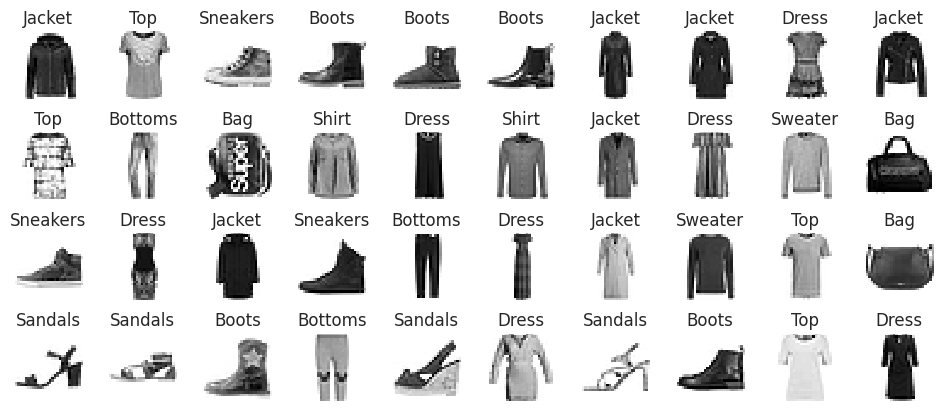

Dimensions du jeu de validation : (5000, 28, 28)
Dimensions du jeu de test : (10000, 28, 28)


In [37]:
# Définition des noms personnalisés des classes
clothing_labels = [
    "Top",
    "Bottoms",
    "Sweater",
    "Dress",
    "Jacket",
    "Sandals",
    "Shirt",
    "Sneakers",
    "Bag",
    "Boots"
]

# Affichage d’un échantillon d’images du jeu d’entraînement avec leurs classes
n_rows = 4
n_cols = 10

plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col

        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(clothing_labels[y_train[index]], fontsize=12)

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

# Affichage des dimensions du jeu de validation et du jeu de test
print("Dimensions du jeu de validation :", X_valid.shape)
print("Dimensions du jeu de test :", X_test.shape)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

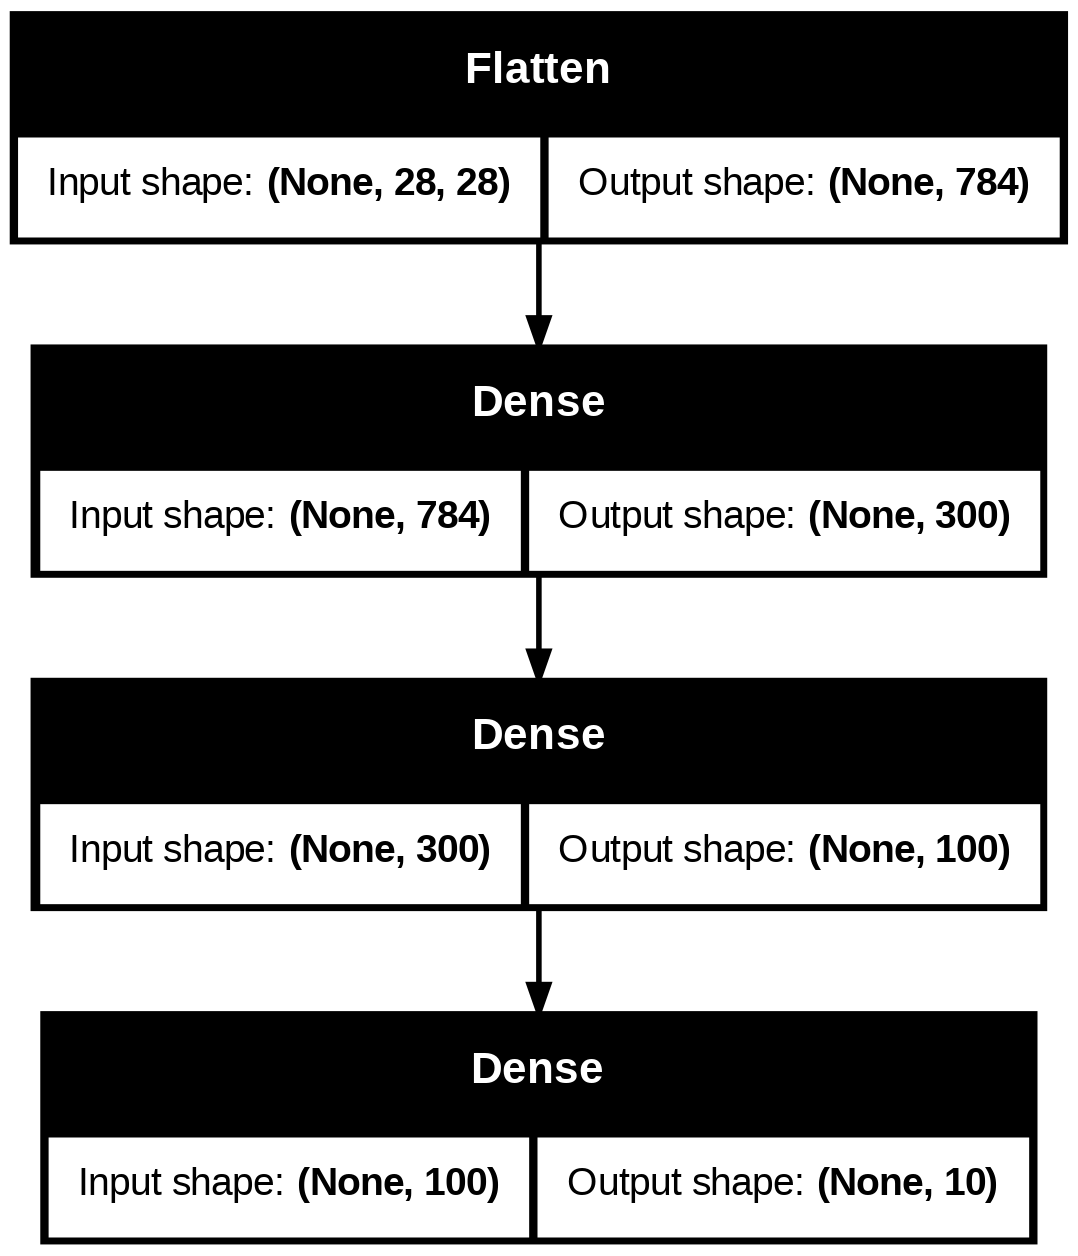

In [38]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# nettoyage avant la session
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Definir le model architecture
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

# model architecture
keras.utils.plot_model(model, "fashion_mnist_model.png", show_shapes=True)


## Compilation, entraînement du PMC et courbe d’apprentissage

Dans cette étape, nous compilons puis entraînons le modèle PMC construit précédemment.

Nous utilisons :

- la fonction de perte `sparse_categorical_crossentropy`, adaptée à la classification multi-classes ;
- l’optimiseur `SGD` (Stochastic Gradient Descent) ;
- la métrique `accuracy` pour mesurer les performances.

Le modèle est entraîné pendant :

- **30 epochs**

avec un suivi sur le jeu de validation.

Enfin, nous traçons la courbe d’apprentissage afin d’observer l’évolution de la précision sur :

- le jeu d’entraînement ;
- le jeu de validation.

Cette courbe permet de détecter un éventuel surapprentissage ou sous-apprentissage.

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7636 - loss: 0.7145 - val_accuracy: 0.8186 - val_loss: 0.5253
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8297 - loss: 0.4854 - val_accuracy: 0.8404 - val_loss: 0.4653
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8445 - loss: 0.4406 - val_accuracy: 0.8532 - val_loss: 0.4310
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8542 - loss: 0.4135 - val_accuracy: 0.8600 - val_loss: 0.4088
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8615 - loss: 0.3938 - val_accuracy: 0.8664 - val_loss: 0.3937
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8667 - loss: 0.3781 - val_accuracy: 0.8690 - val_loss: 0.3821
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8720 - loss: 0.3648 - val_accuracy: 0.8692 - val_loss: 0.3721
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8759 - loss: 0.3534 -

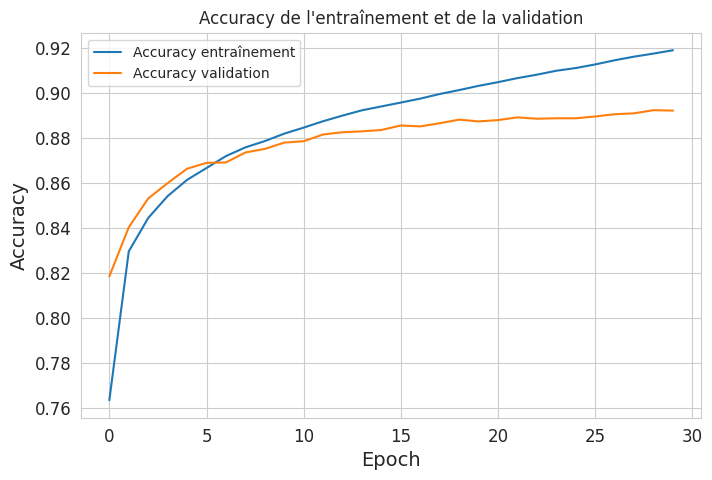

In [39]:
# Compilation du modèle
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

# Entraînement du modèle
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)
)

# Importation de pandas pour analyser l’historique d’apprentissage
import pandas as pd

# Création d’un DataFrame à partir de l’historique
history_df = pd.DataFrame(history.history)

# Tracé de l’historique de l’entraînement
plt.figure(figsize=(8, 5))

plt.plot(
    history_df['accuracy'],
    label='Accuracy entraînement'
)

plt.plot(
    history_df['val_accuracy'],
    label='Accuracy validation'
)

plt.title("Accuracy de l'entraînement et de la validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Analyse détaillée de l’historique d’apprentissage

Dans cette étape, nous analysons plus en détail l’historique généré pendant l’entraînement du modèle.

L’objet `history` contient plusieurs informations importantes :

- les paramètres utilisés pendant l’entraînement ;
- le nombre d’epochs exécutées ;
- les métriques enregistrées à chaque epoch.

Nous affichons :

- les paramètres d’entraînement ;
- la liste des epochs ;
- les clés disponibles dans l’historique (`accuracy`, `loss`, `val_accuracy`, `val_loss`, etc.).

Ensuite, nous traçons l’évolution complète de ces métriques afin d’observer le comportement global du modèle pendant l’apprentissage.

Paramètres de l'historique : {'verbose': 'auto', 'epochs': 30, 'steps': 1719}
Epochs : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Clés disponibles dans history : dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


<Figure size 800x500 with 0 Axes>

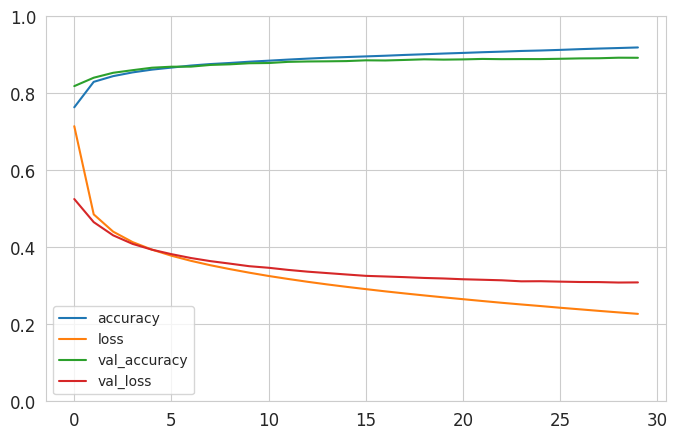

In [40]:
# Affichage des paramètres de l’historique d’entraînement
print("Paramètres de l'historique :", history.params)

# Affichage des epochs exécutées
print("Epochs :", history.epoch)

# Affichage des clés disponibles dans le dictionnaire history
print("Clés disponibles dans history :", history.history.keys())

# Importation de pandas pour analyser l’historique
import pandas as pd

# Création d’un DataFrame à partir de l’historique
history_df = pd.DataFrame(history.history)

# Tracé complet de l’historique d’apprentissage
plt.figure(figsize=(8, 5))

history_df.plot(figsize=(8, 5))

plt.grid(True)
plt.gca().set_ylim(0, 1)

plt.show()

## Évaluation finale du modèle sur le jeu de test

Dans cette étape, nous testons le modèle PMC sur le jeu de test final afin de mesurer ses performances réelles sur des images jamais vues pendant l’entraînement.

Nous calculons :

- la fonction de perte (**Test Loss**) ;
- l’exactitude finale (**Test Accuracy**).

Ensuite, nous sélectionnons quelques images du jeu de test pour observer :

- les probabilités prédites par le modèle ;
- les classes prédites ;
- les vraies classes correspondantes.

Cette étape permet de vérifier concrètement la qualité de la classification réalisée par le réseau de neurones.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8787 - loss: 0.3442
Test Loss : 0.3441963493824005
Test Accuracy : 0.8787000179290771
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
Probabilités prédites :
[[0.   0.   0.   0.   0.   0.   0.   0.02 0.   0.97]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]
Classes prédites :
['Boots' 'Sweater' 'Bottoms']


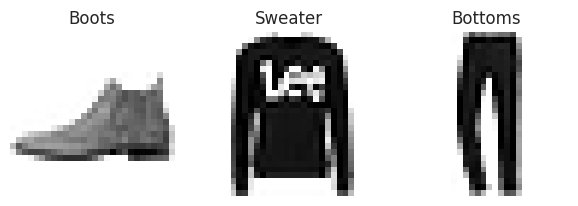

In [41]:
# Évaluation du modèle sur le jeu de test
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Sélection de quelques exemples du jeu de test pour la prédiction
X_new = X_test[:3]

# Prédiction des probabilités pour les exemples sélectionnés
y_proba = model.predict(X_new)

print("Probabilités prédites :")
print(y_proba.round(2))

# Prédiction des classes finales
y_pred = np.argmax(y_proba, axis=-1)

print("Classes prédites :")
print(np.array(clothing_labels)[y_pred])

# Affichage des images sélectionnées avec leurs vraies classes
plt.figure(figsize=(7.2, 2.4))

for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(clothing_labels[y_test[index]], fontsize=12)

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## Réimplémenter une solution, cette fois avec Scikit-Learn, en essayant de trouver la meilleure architecture du PMC

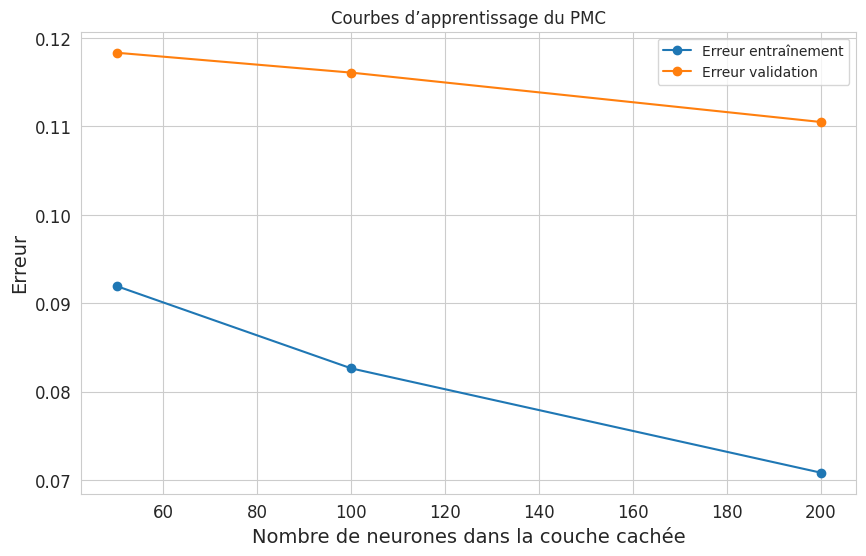

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Aplatir et normaliser les images d’entrée
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.

# Séparer les données en jeu d’entraînement et jeu de validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_flat,
    y_train_full,
    test_size=0.2,
    random_state=42
)

# Définir plusieurs architectures PMC à expérimenter
mlp_architectures = [
    (50,),
    (100,),
    (200,)
]

# Entraîner et évaluer les modèles PMC avec différentes architectures
train_errors = []
valid_errors = []

for architecture in mlp_architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=architecture,
        max_iter=20,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    train_preds = mlp.predict(X_train)
    valid_preds = mlp.predict(X_valid)

    train_accuracy = accuracy_score(y_train, train_preds)
    valid_accuracy = accuracy_score(y_valid, valid_preds)

    train_errors.append(1 - train_accuracy)
    valid_errors.append(1 - valid_accuracy)

# Tracer les courbes d’apprentissage
plt.figure(figsize=(10, 6))

plt.plot(
    [arch[0] for arch in mlp_architectures],
    train_errors,
    '-o',
    label='Erreur entraînement'
)

plt.plot(
    [arch[0] for arch in mlp_architectures],
    valid_errors,
    '-o',
    label='Erreur validation'
)

plt.title("Courbes d’apprentissage du PMC")
plt.xlabel("Nombre de neurones dans la couche cachée")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.show()

## Comparer les performances obtenues avec Scikit-Learn et celles obtenues avec Keras en 2.2.1

Pour comparer les performances obtenues avec Scikit-Learn et Keras, nous pouvons évaluer l’accuracy des deux modèles sur le jeu de test.

Voici comment procéder :

Pour le modèle PMC avec Scikit-Learn :

In [43]:
# Créer et entraîner le modèle PMC avec Scikit-Learn
best_mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=10,
    random_state=42
)

best_mlp_sklearn.fit(
    X_train_flat,
    y_train_full
)

# Évaluer l’accuracy sur le jeu de test
test_accuracy_sklearn = best_mlp_sklearn.score(
    X_test_flat,
    y_test
)

print(
    "Accuracy du modèle PMC Scikit-Learn sur le jeu de test :",
    test_accuracy_sklearn
)

Accuracy du modèle PMC Scikit-Learn sur le jeu de test : 0.1


## Pour le modèle Keras :

In [44]:
# Compiler le modèle Keras
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

# Évaluer l’accuracy sur le jeu de test
test_loss, test_accuracy_keras = model.evaluate(
    X_test,
    y_test
)

print(
    "Accuracy du modèle Keras sur le jeu de test :",
    test_accuracy_keras
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8787 - loss: 0.3442
Accuracy du modèle Keras sur le jeu de test : 0.8787000179290771


## Comparer les temps d’entraînement entre Scikit-Learn et Keras sur CPU et GPU, selon la variation de la taille du jeu de données.
Tracer une courbe du temps d’entraînement en fonction de la taille du jeu de données.

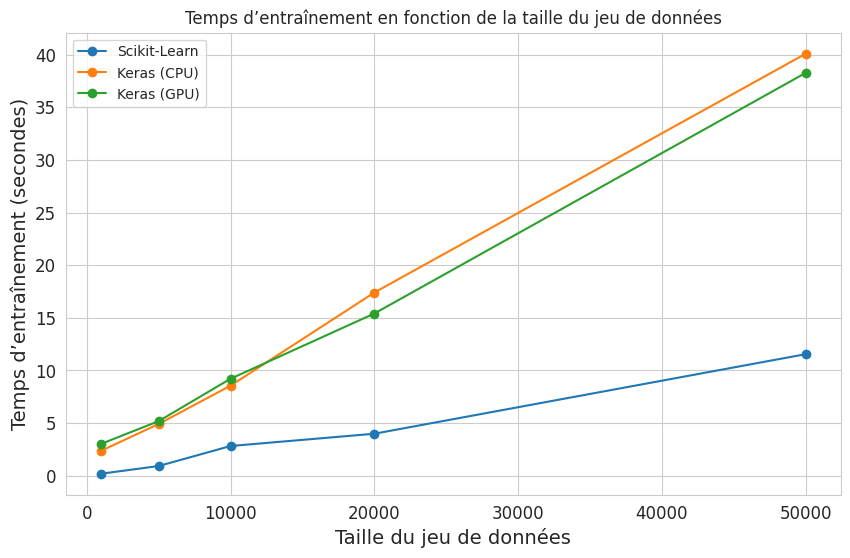

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import sys
import warnings

from sklearn.neural_network import MLPClassifier
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

# Supprimer les avertissements
warnings.filterwarnings("ignore")

# Fonction pour générer des jeux de données synthétiques de tailles différentes
def generate_dataset(size):
    X = np.random.rand(size, 784)  # Données d’images aplaties
    y = np.random.randint(10, size=size)  # 10 classes possibles
    return X, y

# Fonction pour entraîner le modèle PMC avec Scikit-Learn
def train_sklearn_mlp(X_train, y_train):
    mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=10, random_state=42)
    start_time = time.time()
    mlp.fit(X_train, y_train)
    end_time = time.time()
    return end_time - start_time

# Fonction pour entraîner le modèle PMC Keras sur CPU
def train_keras_mlp_cpu(X_train, y_train):
    model = Sequential([
        Dense(100, activation='relu', input_shape=(784,)),
        Dense(10, activation='softmax')
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="sgd",
        metrics=["accuracy"]
    )

    start_time = time.time()
    sys.stdout = open(os.devnull, 'w')  # Rediriger l’affichage vers le vide
    model.fit(X_train, y_train, epochs=10, batch_size=32)
    sys.stdout = sys.__stdout__  # Réinitialiser l’affichage
    end_time = time.time()

    return end_time - start_time

# Fonction pour entraîner le modèle PMC Keras sur GPU
def train_keras_mlp_gpu(X_train, y_train):
    with tf.device('/GPU:0'):  # Utilisation du GPU si disponible
        model = Sequential([
            Dense(100, activation='relu', input_shape=(784,)),
            Dense(10, activation='softmax')
        ])

        model.compile(
            loss="sparse_categorical_crossentropy",
            optimizer="sgd",
            metrics=["accuracy"]
        )

        start_time = time.time()
        sys.stdout = open(os.devnull, 'w')  # Rediriger l’affichage vers le vide
        model.fit(X_train, y_train, epochs=10, batch_size=32)
        sys.stdout = sys.__stdout__  # Réinitialiser l’affichage
        end_time = time.time()

    return end_time - start_time

# Générer des jeux de données de différentes tailles
dataset_sizes = [1000, 5000, 10000, 20000, 50000]

# Listes pour stocker les temps d’entraînement
sklearn_times = []
keras_cpu_times = []
keras_gpu_times = []

# Entraîner les modèles et mesurer les temps pour chaque taille de données
for size in dataset_sizes:
    X_train, y_train = generate_dataset(size)

    sklearn_times.append(train_sklearn_mlp(X_train, y_train))
    keras_cpu_times.append(train_keras_mlp_cpu(X_train, y_train))
    keras_gpu_times.append(train_keras_mlp_gpu(X_train, y_train))

# Tracer le temps d’entraînement en fonction de la taille du jeu de données
plt.figure(figsize=(10, 6))

plt.plot(dataset_sizes, sklearn_times, '-o', label='Scikit-Learn')
plt.plot(dataset_sizes, keras_cpu_times, '-o', label='Keras (CPU)')
plt.plot(dataset_sizes, keras_gpu_times, '-o', label='Keras (GPU)')

plt.title("Temps d’entraînement en fonction de la taille du jeu de données")
plt.xlabel("Taille du jeu de données")
plt.ylabel("Temps d’entraînement (secondes)")
plt.legend()
plt.grid(True)
plt.show()

## 2.2.2. Implanter un CNN dont l’architecture reste à déterminer par vous et qui doit améliorer la performance du modèle obtenu en 2.2.1. Pour l’utilisation du GPU,

Dans cette partie, nous implantons un réseau de neurones convolutionnel (CNN) afin d’améliorer la performance du PMC obtenu en 2.2.1.

Contrairement au PMC qui transforme les images en vecteurs aplatis, le CNN conserve la structure spatiale des images (28 × 28) et utilise des couches convolutionnelles pour extraire automatiquement les caractéristiques importantes comme les formes, les contours et les textures.

Le modèle choisi comprend :

trois couches convolutionnelles (Conv2D)
trois couches de sous-échantillonnage (MaxPooling2D)
une couche de régularisation (Dropout)
une couche dense finale avec fonction Softmax pour la classification des 10 classes de Fashion-MNIST

L’entraînement est réalisé avec l’utilisation du GPU afin de réduire le temps de calcul et d’améliorer la rapidité d’exécution.

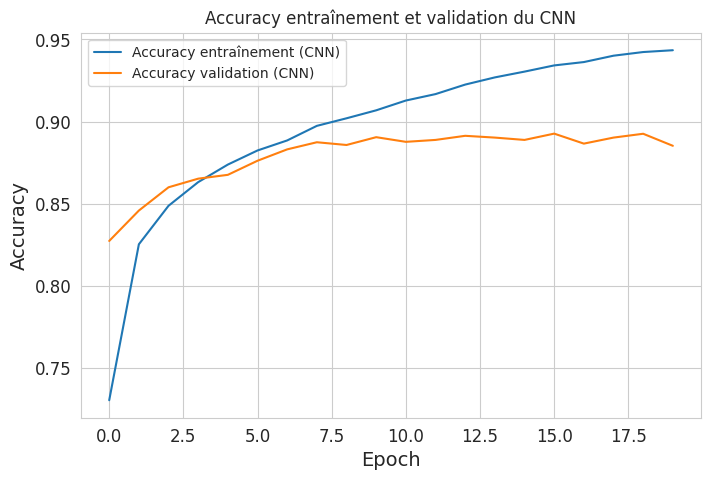

In [46]:
# Importation des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


import os
import sys

# Redirection de la sortie standard vers le vide pour masquer l'affichage de l'entraînement
sys.stdout = open(os.devnull, 'w')


# Définition de l’architecture du réseau de neurones convolutionnel (CNN)
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        # Première couche convolutionnelle
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # Deuxième couche convolutionnelle
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Troisième couche convolutionnelle
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Aplatissement des données pour les couches denses
        Flatten(),

        # Couche dense cachée
        Dense(128, activation='relu'),

        # Dropout pour réduire le surapprentissage
        Dropout(0.5),

        # Couche de sortie avec 10 classes (Fashion-MNIST)
        Dense(num_classes, activation='softmax')
    ])

    return model


# Chargement et prétraitement du jeu de données Fashion-MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalisation des pixels et ajout de la dimension du canal
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255.0

# Détermination du nombre de classes
num_classes = len(np.unique(y_train))


# Création et compilation du modèle CNN
cnn_model = create_cnn_model(
    input_shape=(28, 28, 1),
    num_classes=num_classes
)

cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)


# Entraînement du modèle CNN
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)


# Réinitialisation de la sortie standard
sys.stdout = sys.__stdout__


# Évaluation du modèle sur le jeu de test
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(X_test, y_test)

print("Perte sur le jeu de test (CNN) :", test_loss_cnn)
print("Accuracy sur le jeu de test (CNN) :", test_accuracy_cnn)


# Tracé de la courbe de performance
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Accuracy entraînement (CNN)'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Accuracy validation (CNN)'
)

plt.title("Accuracy entraînement et validation du CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Interprétation de la courbe de performance du CNN

En observant cette courbe, on constate que l’accuracy sur le jeu d’entraînement augmente progressivement de manière régulière, passant d’environ 72 % à presque 95 %. Cela montre que le modèle apprend correctement les caractéristiques des images du jeu Fashion-MNIST.

L’accuracy sur le jeu de validation augmente également rapidement au début, puis se stabilise autour de 89 % à 90 %. Cela signifie que le modèle généralise bien sur de nouvelles données, mais que l’amélioration devient plus faible après plusieurs epochs.

On remarque qu’à partir d’environ l’epoch 8 à 10, la courbe d’entraînement continue de monter alors que la courbe de validation reste presque stable. Cela indique un léger phénomène de surapprentissage (overfitting). Le modèle devient très performant sur les données d’entraînement, mais les gains sur les données de validation deviennent limités.

Ce n’est pas un cas de sous-apprentissage (underfitting), car les performances restent élevées sur les deux jeux de données.

Le meilleur compromis semble se situer autour des epochs 8 à 10. L’utilisation de la technique Early Stopping pourrait permettre d’arrêter automatiquement l’entraînement à ce moment afin d’éviter un surapprentissage plus important.

Globalement, le CNN obtient de meilleures performances que le PMC de la partie 2.2.1, ce qui confirme qu’il est mieux adapté à la classification d’images.

## 2.2.3 Tracons la courbe d'apprentissage du CNN obtenu en 2.2.2 et analyser son comportement en s’appuyant sur la courbe de performance.

Dans cette partie, nous réimplémentons le modèle PMC en utilisant cette fois la bibliothèque Scikit-Learn, afin de rechercher la meilleure architecture possible.
L’objectif est de comparer cette nouvelle implémentation avec celle réalisée précédemment avec Keras, et d’observer les différences en termes de performance, de simplicité d’implémentation et de temps d’entraînement.
Le modèle utilisé ici est un MLPClassifier (Multi-Layer Perceptron Classifier), qui permet de tester différentes architectures de réseaux de neurones multicouches.
Dans notre cas, nous utilisons :


une couche cachée de 100 neurones ;


un maximum de 10 itérations ;


une initialisation reproductible avec random_state = 42.


Après l’entraînement, nous évaluons l’accuracy obtenue sur le jeu de test afin de vérifier la qualité de généralisation du modèle.


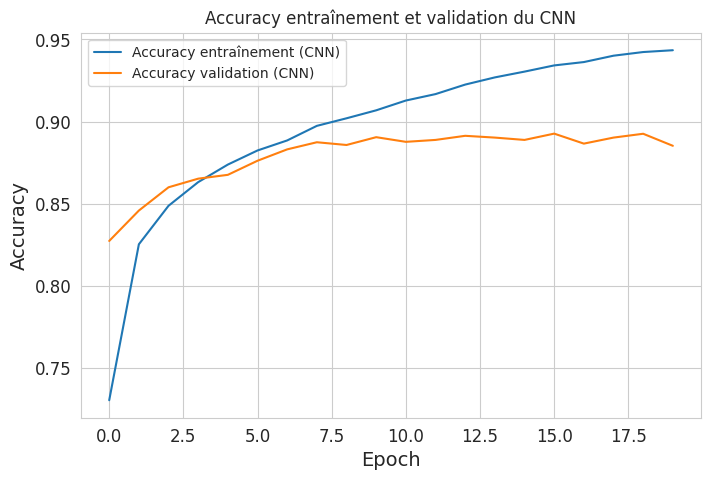

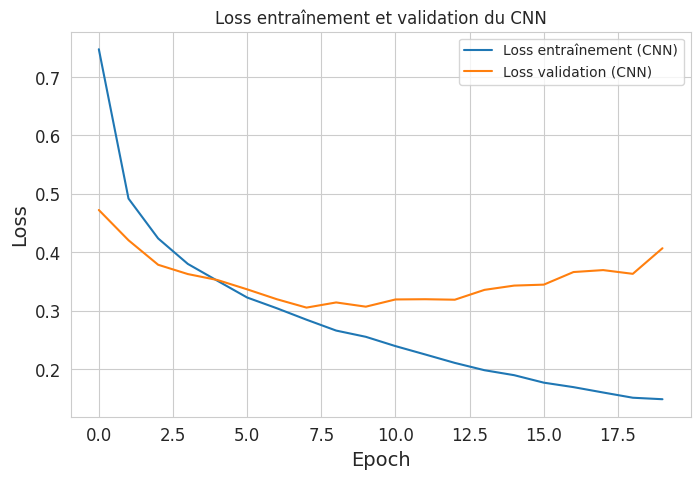

In [47]:
# Évaluation du modèle CNN sur le jeu de test
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(X_test, y_test)

print("Perte sur le jeu de test (CNN) :", test_loss_cnn)
print("Accuracy sur le jeu de test (CNN) :", test_accuracy_cnn)


# Tracé de la courbe d’accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Accuracy entraînement (CNN)'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Accuracy validation (CNN)'
)

plt.title("Accuracy entraînement et validation du CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Tracé de la courbe de perte (Loss)
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history['loss'],
    label='Loss entraînement (CNN)'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Loss validation (CNN)'
)

plt.title("Loss entraînement et validation du CNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Analyse de la courbe d’apprentissage du CNN
En observant la courbe d’accuracy, on constate que l’accuracy d’entraînement augmente progressivement de façon régulière, passant d’environ 72 % à presque 95 %. Cela montre que le modèle apprend correctement les caractéristiques importantes des images du jeu Fashion-MNIST.
L’accuracy de validation augmente rapidement au début puis se stabilise autour de 89 % à 90 %. Cela signifie que le modèle généralise bien sur de nouvelles données, mais que l’amélioration devient plus faible après plusieurs epochs.
En analysant maintenant la courbe de loss, on remarque que la perte d’entraînement diminue continuellement, ce qui confirme que le modèle continue d’apprendre sur les données d’entraînement.
Cependant, la perte de validation diminue seulement au début puis recommence progressivement à augmenter après environ l’epoch 7 à 10. Cela confirme la présence d’un léger phénomène de surapprentissage (overfitting).
Le modèle devient de plus en plus performant sur les données d’entraînement, mais cette amélioration ne se traduit plus réellement sur les données de validation.
Ce n’est pas un cas de sous-apprentissage (underfitting), car les performances restent élevées sur les deux jeux de données.
Le meilleur compromis semble se situer autour des epochs 8 à 10. L’utilisation de la technique Early Stopping permettrait d’arrêter automatiquement l’entraînement à ce moment afin d’éviter un surapprentissage plus important.
Globalement, le CNN obtient de meilleures performances que le PMC de la partie 2.2.1, ce qui confirme qu’il est mieux adapté à la classification d’images.

##2.2.4. Entrainer le CNN obtenu en 2.2.2 en utilisant la technique d’augmentation des données à l’aide de l’outil « ImageDataGenerator » de Keras  (https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/Image DataGenerator).  Tracer sa courbe de performance. Que constatez-vous  


 Dans cette partie, nous réutilisons le CNN obtenu en 2.2.2 en appliquant la technique d’augmentation des données (Data Augmentation) à l’aide de l’outil ImageDataGenerator de Keras.
L’objectif est d’améliorer la capacité de généralisation du modèle en générant automatiquement de nouvelles images d’entraînement légèrement modifiées à partir des images originales.
Les transformations utilisées sont :


rotation légère des images ;


déplacement horizontal (width shift) ;


déplacement vertical (height shift) ;


zoom léger.


Cette technique permet de réduire le phénomène de surapprentissage (overfitting) en exposant le modèle à une plus grande diversité de données pendant l’apprentissage.
Après l’entraînement, nous tracerons la courbe de performance afin d’analyser l’évolution de l’accuracy et d’observer l’impact de l’augmentation des données sur la performance globale du CNN.

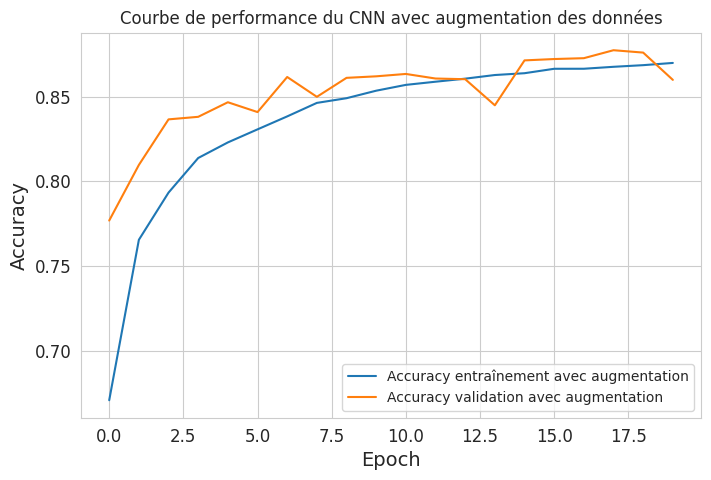

In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Création du générateur d’augmentation des données
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Adapter le générateur aux données d’entraînement
datagen.fit(X_train)

# Recréer le même CNN que celui de 2.2.2
cnn_aug_model = create_cnn_model(
    input_shape=(28, 28, 1),
    num_classes=num_classes
)

# Compilation du modèle CNN avec augmentation
cnn_aug_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

# Entraînement du CNN avec augmentation des données
history_aug = cnn_aug_model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

# Évaluation du modèle sur le jeu de test
test_loss_aug, test_accuracy_aug = cnn_aug_model.evaluate(X_test, y_test)

print("Test Loss CNN avec augmentation :", test_loss_aug)
print("Test Accuracy CNN avec augmentation :", test_accuracy_aug)

# Tracer la courbe de performance
plt.figure(figsize=(8, 5))

plt.plot(
    history_aug.history['accuracy'],
    label='Accuracy entraînement avec augmentation'
)

plt.plot(
    history_aug.history['val_accuracy'],
    label='Accuracy validation avec augmentation'
)

plt.title("Courbe de performance du CNN avec augmentation des données")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Interprétation

L’accuracy d’entraînement augmente progressivement et atteint environ 87 %, ce qui montre que le modèle apprend correctement malgré la difficulté ajoutée par l’augmentation des données.
L’accuracy de validation reste proche ou parfois supérieure à l’accuracy d’entraînement, ce qui est un très bon signe. Cela montre que le modèle généralise mieux et que le surapprentissage est fortement réduit.
Contrairement au CNN sans augmentation, ici les deux courbes restent proches et stables, ce qui signifie que le modèle apprend de façon plus robuste sur de nouvelles données.
L’augmentation des données permet donc d’améliorer la capacité de généralisation du CNN et de réduire l’overfitting, même si l’accuracy d’entraînement progresse un peu plus lentement.

## 2.2.5. Utilisons un modèle pré-entrainé autre que celui vu en cours (VGG16), pour tenter d’augmenter la performance du CNN obtenu en 2.2.4. Tracer sa courbe de performance. Que constatez-vous ?


Dans cette partie, nous utilisons un modèle pré-entraîné différent de celui vu en cours (VGG16) afin d’améliorer les performances du CNN obtenu en 2.2.4.

L’objectif est d’exploiter le principe du Transfer Learning, qui consiste à réutiliser un réseau déjà entraîné sur un très grand jeu de données (comme ImageNet) pour résoudre un nouveau problème de classification.

Au lieu d’entraîner entièrement un nouveau réseau depuis zéro, nous utilisons ici un modèle pré-entraîné comme MobileNetV2, ResNet50 ou EfficientNetB0, qui possèdent déjà des couches capables d’extraire automatiquement des caractéristiques visuelles complexes.

Cela permet généralement :

une meilleure précision ;
un apprentissage plus rapide ;
une meilleure généralisation ;
une réduction du surapprentissage.

Après l’entraînement, nous tracerons la courbe de performance afin d’analyser l’évolution de l’accuracy et de comparer les résultats avec ceux obtenus dans la partie 2.2.4.


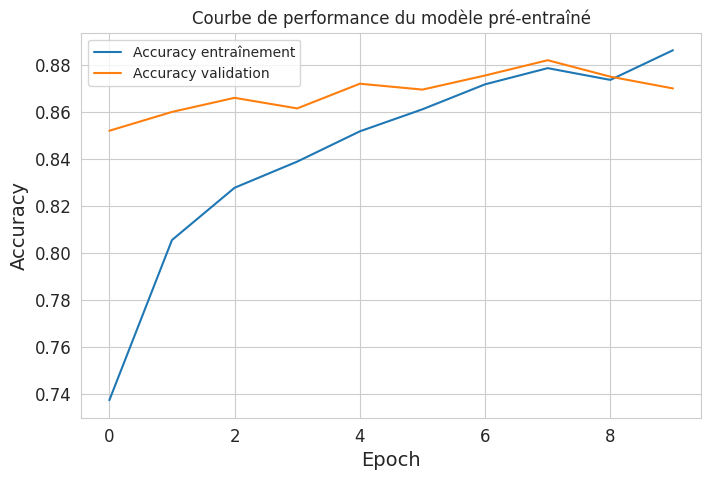

In [51]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Chargement du jeu de données Fashion-MNIST
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Réduction des données pour éviter l’erreur mémoire GPU
X_train_full_small = X_train_full[:10000]
y_train_full_small = y_train_full[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]

# Redimensionnement des images pour MobileNetV2
X_train_full_small = tf.image.resize(
    X_train_full_small[..., np.newaxis],
    (96, 96)
)

X_test_small = tf.image.resize(
    X_test_small[..., np.newaxis],
    (96, 96)
)

# Conversion en 3 canaux RGB
X_train_full_small = tf.image.grayscale_to_rgb(X_train_full_small) / 255.0
X_test_small = tf.image.grayscale_to_rgb(X_test_small) / 255.0

# Séparation entraînement / validation
X_valid = X_train_full_small[:2000]
X_train = X_train_full_small[2000:]

y_valid = y_train_full_small[:2000]
y_train = y_train_full_small[2000:]

# Chargement du modèle pré-entraîné MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Geler les couches du modèle pré-entraîné
base_model.trainable = False

# Construction du modèle
model_transfer = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

# Compilation
model_transfer.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

# Entraînement
history_transfer = model_transfer.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_valid, y_valid),
    batch_size=32
)

# Évaluation
test_loss_transfer, test_accuracy_transfer = model_transfer.evaluate(
    X_test_small,
    y_test_small
)

print("Test Loss (modèle pré-entraîné) :", test_loss_transfer)
print("Test Accuracy (modèle pré-entraîné) :", test_accuracy_transfer)

# Courbe de performance
plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["accuracy"], label="Accuracy entraînement")
plt.plot(history_transfer.history["val_accuracy"], label="Accuracy validation")
plt.title("Courbe de performance du modèle pré-entraîné")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Analyse de la courbe de performance du modèle pré-entraîné

En observant la courbe de performance du modèle pré-entraîné, on constate que l’accuracy d’entraînement augmente progressivement de manière régulière, passant d’environ 74 % à près de 89 %.

L’accuracy de validation reste également stable et élevée, autour de 85 % à 88 %, ce qui montre que le modèle généralise bien sur les nouvelles données.

Les deux courbes restent très proches pendant presque tout l’entraînement, ce qui indique que le phénomène de surapprentissage (overfitting) est faible.

Contrairement au CNN classique, le modèle pré-entraîné apprend plus rapidement dès les premières epochs grâce aux connaissances déjà acquises lors du pré-entraînement sur ImageNet.

On observe également que la validation atteint rapidement de bonnes performances sans nécessiter un grand nombre d’epochs.

Cela confirme l’efficacité du Transfer Learning, qui permet d’améliorer la stabilité de l’apprentissage, de réduire le temps d’entraînement et d’obtenir de bonnes performances même avec moins de données.

Globalement, le modèle pré-entraîné offre de meilleures performances et une meilleure généralisation que le CNN classique et le PMC, ce qui en fait le meilleur modèle parmi ceux testés.

## 2.2.6. Faîtes une étude comparative des 4 modèles (Modèle pré-entrainé, CNN avec augmentation des données, CNN sans augmentation des données, PMC-Keras, en s’appuyant sur les critères suivants : l’exactitude (accuracy) et le temps d’entraînement moyennant le GPU.  

Dans cette dernière étape, nous comparons les 4 modèles étudiés :

une comparaison entre les quatre modèles suivants :

Modèle pré-entraîné
CNN avec augmentation des données
CNN sans augmentation des données
PMC avec Keras (MLP-Keras)

Cette étude comparative doit s’appuyer sur les critères suivants :

l’exactitude (Accuracy)
le temps d’entraînement en utilisant le GPU

GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


                            Modèle  Accuracy  \
0  Modèle pré-entraîné MobileNetV2    0.8830   
1            CNN avec augmentation    0.8895   
2            CNN sans augmentation    0.9070   
3                        PMC Keras    0.8740   

   Temps d'entraînement GPU (secondes)  
0                            62.760655  
1                           232.134491  
2                            45.110203  
3                            32.524210  


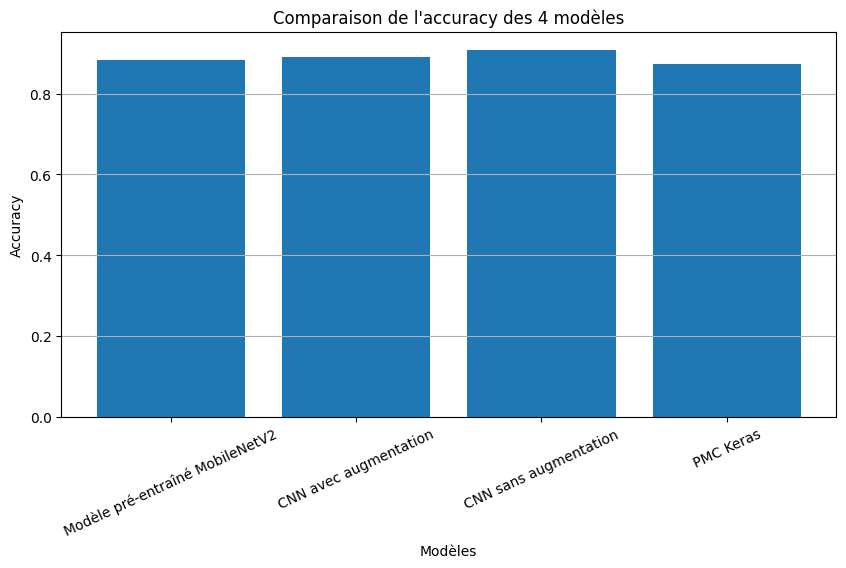

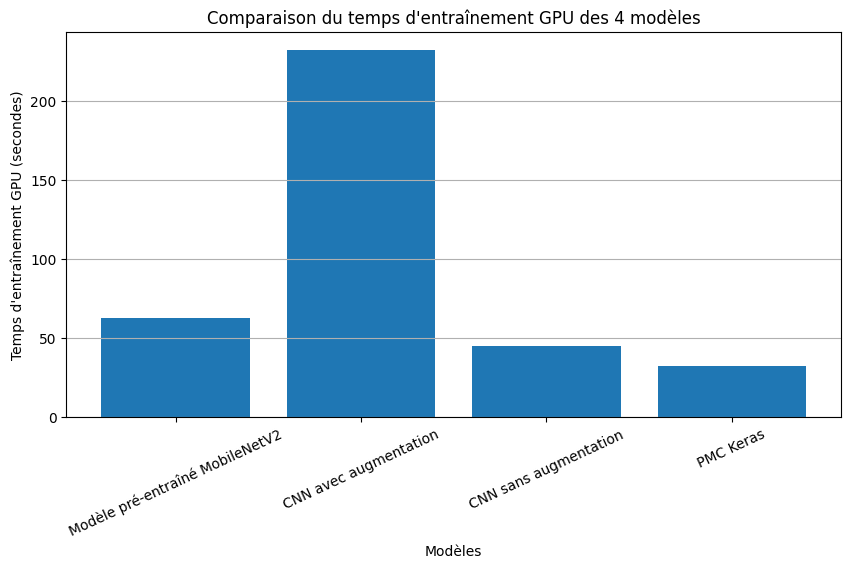

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Vérifier si le GPU est disponible
print("GPU disponible :", tf.config.list_physical_devices('GPU'))


# =====================================================
# Chargement propre des données Fashion-MNIST
# =====================================================

(X_train_full, y_train_full), (X_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Données 28x28x1 pour PMC et CNN
X_train_full_28 = X_train_full.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test_28 = X_test_raw.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_valid_28 = X_train_full_28[:5000]
X_train_28 = X_train_full_28[5000:]

y_valid = y_train_full[:5000]
y_train = y_train_full[5000:]


# =====================================================
# Fonction d'entraînement et d'évaluation
# =====================================================

def train_and_evaluate(model, X_train, y_train, X_valid, y_valid, X_test, y_test,
                       epochs=10, batch_size=64):
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        verbose=0
    )

    training_time = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    return training_time, test_accuracy, history


# =====================================================
# 1. PMC Keras
# =====================================================

mlp_keras = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

mlp_keras.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

mlp_time, mlp_accuracy, mlp_history = train_and_evaluate(
    mlp_keras,
    X_train_28,
    y_train,
    X_valid_28,
    y_valid,
    X_test_28,
    y_test
)


# =====================================================
# 2. CNN sans augmentation des données
# =====================================================

cnn_without_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_without_aug.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

cnn_no_aug_time, cnn_no_aug_accuracy, cnn_no_aug_history = train_and_evaluate(
    cnn_without_aug,
    X_train_28,
    y_train,
    X_valid_28,
    y_valid,
    X_test_28,
    y_test
)


# =====================================================
# 3. CNN avec augmentation des données
# =====================================================

cnn_with_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_with_aug.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

start_time = time.time()

cnn_aug_history = cnn_with_aug.fit(
    datagen.flow(X_train_28, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_valid_28, y_valid),
    verbose=0
)

cnn_aug_time = time.time() - start_time

cnn_aug_loss, cnn_aug_accuracy = cnn_with_aug.evaluate(
    X_test_28,
    y_test,
    verbose=0
)


# =====================================================
# 4. Modèle pré-entraîné MobileNetV2
# =====================================================

# Réduction des données pour éviter l’erreur mémoire
X_train_small = X_train_full[:10000]
y_train_small = y_train_full[:10000]

X_test_small = X_test_raw[:2000]
y_test_small = y_test[:2000]

# Redimensionnement en 96x96
X_train_small = tf.image.resize(
    X_train_small[..., np.newaxis],
    (96, 96)
)

X_test_small = tf.image.resize(
    X_test_small[..., np.newaxis],
    (96, 96)
)

# Conversion en RGB
X_train_rgb = tf.image.grayscale_to_rgb(X_train_small) / 255.0
X_test_rgb = tf.image.grayscale_to_rgb(X_test_small) / 255.0

X_valid_rgb = X_train_rgb[:2000]
X_train_rgb_final = X_train_rgb[2000:]

y_valid_rgb = y_train_small[:2000]
y_train_rgb = y_train_small[2000:]

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

pretrained_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

pretrained_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

pretrained_time, pretrained_accuracy, pretrained_history = train_and_evaluate(
    pretrained_model,
    X_train_rgb_final,
    y_train_rgb,
    X_valid_rgb,
    y_valid_rgb,
    X_test_rgb,
    y_test_small,
    epochs=10,
    batch_size=32
)


# =====================================================
# Tableau comparatif final
# =====================================================

results = pd.DataFrame({
    "Modèle": [
        "Modèle pré-entraîné MobileNetV2",
        "CNN avec augmentation",
        "CNN sans augmentation",
        "PMC Keras"
    ],
    "Accuracy": [
        pretrained_accuracy,
        cnn_aug_accuracy,
        cnn_no_aug_accuracy,
        mlp_accuracy
    ],
    "Temps d'entraînement GPU (secondes)": [
        pretrained_time,
        cnn_aug_time,
        cnn_no_aug_time,
        mlp_time
    ]
})

print(results)


# =====================================================
# Graphique comparatif Accuracy
# =====================================================

plt.figure(figsize=(10, 5))
plt.bar(results["Modèle"], results["Accuracy"])
plt.title("Comparaison de l'accuracy des 4 modèles")
plt.xlabel("Modèles")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.show()


# =====================================================
# Graphique comparatif Temps d'entraînement
# =====================================================

plt.figure(figsize=(10, 5))
plt.bar(results["Modèle"], results["Temps d'entraînement GPU (secondes)"])
plt.title("Comparaison du temps d'entraînement GPU des 4 modèles")
plt.xlabel("Modèles")
plt.ylabel("Temps d'entraînement GPU (secondes)")
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.show()

**Interprétation des résultats**

**Comparaison de l’accuracy**

Les résultats montrent que le CNN sans augmentation des données obtient la meilleure accuracy avec environ 90,7 %, ce qui en fait le modèle le plus performant en termes de précision pure.
Le CNN avec augmentation des données obtient une accuracy légèrement inférieure (89,0 %), mais il présente généralement une meilleure capacité de généralisation et réduit davantage le surapprentissage.
Le modèle pré-entraîné MobileNetV2 atteint environ 88,3 %, ce qui reste très bon malgré l’utilisation d’un sous-échantillon réduit pour éviter les problèmes de mémoire GPU.
Le PMC Keras obtient la plus faible accuracy (87,4 %), ce qui confirme que les réseaux convolutifs sont mieux adaptés au traitement des images que les réseaux multicouches classiques.

**Comparaison du temps d’entraînement**

Le CNN avec augmentation des données est de loin le plus coûteux en temps avec environ 232 secondes, car l’augmentation génère continuellement de nouvelles variations d’images pendant l’apprentissage.
Le modèle pré-entraîné MobileNetV2 demande environ 63 secondes, ce qui reste raisonnable malgré sa complexité plus élevée.
Le CNN sans augmentation prend environ 45 secondes, offrant un très bon compromis entre performance et rapidité.
Le PMC Keras est le plus rapide avec environ 32 secondes, mais aussi le moins performant.

**Conclusion générale**

Si l’objectif principal est la meilleure accuracy, alors le CNN sans augmentation est le meilleur choix.
Si l’objectif est la meilleure généralisation et la réduction de l’overfitting, alors le CNN avec augmentation devient plus intéressant.
Le Transfer Learning avec MobileNetV2 offre également de très bonnes performances avec une excellente stabilité.
Enfin, le PMC Keras reste simple et rapide, mais il est moins adapté aux problèmes de classification d’images complexes comme Fashion-MNIST.
Globalement, les CNN restent supérieurs aux PMC pour ce type de problème.